![COVID19](https://kominfosandi.kamparkab.go.id/wp-content/uploads/2021/08/banner.png)

# **Corona Virus (COVID-19) classification**



## **Business understanding**

### **Project Background & Context**

The COVID-19 pandemic has underscored the urgent need for efficient methods to identify potentially infected individuals. Although PCR and antigen tests remain the gold standards for diagnosis, these procedures are often resource-intensive, time-consuming, and not always accessible—particularly in remote or resource-limited regions.

The dataset provided by the Ministry of Health contains key patient information, including:

* Demographics (e.g., age group, gender)

* Symptoms (e.g., cough, fever, sore throat, shortness of breath, headache)

* Testing context (e.g., contact with confirmed cases, recent travel, or other test indications)

* Laboratory-confirmed test results 

By applying machine learning techniques, this project aims to predict the likelihood of a positive COVID-19 test based on these features.
Such predictive modeling can serve as a valuable decision-support tool for healthcare providers by:

* Assisting in early identification of high-risk or suspected cases before confirmatory testing.

* Prioritizing testing efforts and optimizing limited medical resources, particularly during outbreak surges or in underserved areas.

### **Problem Statement**

* How do demographic, symptom, and exposure features influence COVID-19 test results?

* Which machine learning model achieves the best performance on unseen data and what are the best model parameters?

* Which features contribute most to prediction accuracy?

### **Analytical Approach**

This analysis aims to uncover patterns that differentiate patients who test positive for COVID-19 from those who test negative. The model should be able to predict based on the given historical data from the hospital/healthcare institutions. In addition to that, we want to know which variables that are crucial in increasing probability to get the positive test result. There are several steps of approach to achieve our objective that consist of:

* Data Understanding & Preparation – Explore the dataset, check missing values, and perform encoding for categorical variables.

* Feature Engineering – Transform features (e.g., impute missing demographics, create binary symptom indicators).

* Model Development – Train multiple classification models (e.g., logistic regression, random forest, gradient boosting, etc.) to predict COVID-19 positivity.

* Model Evaluation – Compare and evaluate model performances using metrics such as accuracy, precision, recall, F1-score, ROC-AUC curve, and precision-recall curve.

* Hyperparameter tunning - Perform further improvement of the models. Select the top 3 best models and conduct hyperparameter tunning using randomized search to find the optimum parameters.

* Interpretability – Identify the most influential features driving predictions (e.g., feature importance, permutation importance for global explanation, and LIME for local explanation).

#### **Metric evaluation**

In this study, the target variable represents the COVID-19 test result:

Target:

* 0 : Patient tested negative for COVID-19
* 1 : Patient tested positive for COVID-19



**Error Types**

* Type I Error (False Positive) – The model predicts a patient as COVID-19 positive when they are not.

Impact: Leads to unnecessary testing and resource usage but poses minimal health risk.

* Type II Error (False Negative) – The model predicts a patient as negative when they are actually infected.

Impact: Poses serious health and safety risks since undetected infected individuals may deteriorate and/or spread the virus further.

![confusion matrix](https://www.nbshare.io/static/snapshots/cm_colored_1-min.png)

**Metric prioritization**


Given these implications, Recall is prioritized as the main performance metric because it measures how effectively the model captures all actual positive cases.
The recall formula is:


> **Recall** = True Positive / True Positive + False Negative


A higher recall value indicates the model is better at identifying COVID-19-positive patients, reducing the risk of missed infections.

To complement recall, the Precision-Recall (PR) Curve is also analyzed to evaluate how well the model balances the trade-off between capturing true positives and avoiding false alarms, especially under class imbalance conditions.


## **Data Understanding**

**Initial setup**

In [1]:
# Import required libraries

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data Splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Preprocessing
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder, OrdinalEncoder
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from imblearn.pipeline import Pipeline

# Resampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTENC

# Algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier #deleted
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Model evaluation, metrics, hyperparameter tunning
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import recall_score, classification_report, confusion_matrix, precision_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from matplotlib.colors import LinearSegmentedColormap
from sklearn.base import clone
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Model interpretation
from sklearn.inspection import permutation_importance
import lime
from lime import lime_tabular


# Other libraries
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Settings
plt.style.use('ggplot')

In [3]:
# Loading dataset
COVID19_url = 'https://raw.githubusercontent.com/harishmuh/COVID19_Prediction/refs/heads/main/dataset/Covid_19_Dataset.csv'
data = pd.read_csv(COVID19_url)
data.shape

(278848, 10)

In [4]:
# First rows review
data.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [5]:
# Columns
data.columns

Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='object')

In [6]:
# Data summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  object 
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  object 
 7   age_60_and_above     151528 non-null  object 
 8   gender               259285 non-null  object 
 9   test_indication      278848 non-null  object 
dtypes: float64(5), object(5)
memory usage: 21.3+ MB


**Dataset Description**






| Attribute | Description | Unique Values |
| :--- | :--- | :--- |
| **test_date** | The date when the nasal/oral swab sample was collected from the individual for COVID-19 testing. | YYYY-MM-DD format (e.g., 2020-04-30) |
| **cough** | Indicates if the individual reported or was observed to have a cough symptom at the time of testing. | `0` = No cough symptom reported<br>`1` = Cough symptom present |
| **fever** | Indicates if the individual reported or was observed to have a fever at the time of testing. | `0` = No fever reported<br>`1` = Fever present |
| **sore_throat** | Indicates if the individual reported or was observed to have a sore throat at the time of testing. | `0` = No sore throat reported<br>`1` = Sore throat present |
| **shortness_of_breath** | Indicates if the individual reported or was observed to have difficulty breathing. This is a sign of more severe respiratory involvement. | `0` = No shortness of breath reported<br>`1` = Shortness of breath present |
| **head_ache** | Indicates if the individual reported or was observed to have a headache at the time of testing. | `0` = No headache reported<br>`1` = Headache present |
| **corona_result** | The result of the PCR (Polymerase Chain Reaction) test for the SARS-CoV-2 virus. | `negative` = Virus not detected<br>`positive` = Virus detected<br>`other` = Inconclusive, invalid, or voided test |
| **age_60_and_above** | A risk-based age categorization indicating if the individual is in the higher-risk age group. | `No` = Individual is under 60 years old<br>`Yes` = Individual is 60 years or older<br>`None` = Age data was missing or not recorded |
| **gender** | The gender of the individual tested for COVID-19. | `female` = Female individual<br>`male` = Male individual<br>`None` = Gender data was missing or not recorded |
| **test_indication** | The primary reason or exposure category that prompted the COVID-19 test. | `Abroad` = Testing due to return from international travel<br>`Contact with confirmed` = Testing due to known exposure to a confirmed case<br>`Other` = All other reasons (symptoms, general screening, etc.) |


**Key Notes for Analysis**:
- **Target Variable**: `corona_result` is typically the target for predictive modeling (classifying positive vs negative cases)
- **Missing Values**: `None` values represent missing data.
- **Symptoms Data**: Symptom fields are based on self-reporting or initial observation at time of testing
- **Data Source**: Israeli Ministry of Health (original source:[data.go.il](https://data.gov.il/dataset/covid-19))

In [7]:
# Displaying dimension of the dataset.
print('Length of Dataset: ', data.shape[0])
print('Number of Attributes: ', data.shape[1])

Length of Dataset:  278848
Number of Attributes:  10


### **Unique values assesment**

In [8]:
# Unique values
# Check data type, null values, and unique values ​​of each column
pd.DataFrame({
    'feature': data.columns.values,
    'data_type': data.dtypes.values,
    'missing values': data.isna().mean().values * 100,
    'negative': [True if data[col].dtype == int and (data[col] < 0).any() else False for col in data.columns],
    'n_unique': data.nunique().values,
    'sample_unique': [data[col].unique() for col in data.columns]
})

,feature,data_type,missing values,negative,n_unique,sample_unique
0,test_date,object,0.000000,False,51,"[2020-04-30, 2020-04-29, 2020-04-28, 2020-04-2..."
1,cough,float64,0.090372,False,2,"[0.0, 1.0, nan]"
2,fever,float64,0.090372,False,2,"[0.0, 1.0, nan]"
3,sore_throat,float64,0.000359,False,2,"[0.0, 1.0, nan]"
4,shortness_of_breath,float64,0.000359,False,2,"[0.0, 1.0, nan]"
5,head_ache,float64,0.000359,False,2,"[0.0, 1.0, nan]"
6,corona_result,object,0.000000,False,3,"[negative, positive, other]"
7,age_60_and_above,object,45.659284,False,2,"[nan, Yes, No]"
8,gender,object,7.015650,False,2,"[female, male, nan]"
9,test_indication,object,0.000000,False,3,"[Other, Abroad, Contact with confirmed]"


### **Statistical descriptive**

In [9]:
# Statistical descriptive
display(data.describe().T, data.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
cough,278596.0,0.151574,0.358608,0.0,0.0,0.0,0.0,1.0
fever,278596.0,0.078077,0.268294,0.0,0.0,0.0,0.0,1.0
sore_throat,278847.0,0.006907,0.082821,0.0,0.0,0.0,0.0,1.0
shortness_of_breath,278847.0,0.005655,0.074990,0.0,0.0,0.0,0.0,1.0
head_ache,278847.0,0.008657,0.092640,0.0,0.0,0.0,0.0,1.0


,count,unique,top,freq
test_date,278848,51,2020-04-20,10921
corona_result,278848,3,negative,260227
age_60_and_above,151528,2,No,125703
gender,259285,2,female,130158
test_indication,278848,3,Other,242741


**Key Insights**

* Symptom Variables (cough, fever, sore throat, shortness_of_breath, head_ache): Most individuals reported no symptoms.

  * Cough (15%) and fever (8%) are the most common.

  * Other symptoms (sore throat, shortness of breath, headache) are <1% each.

* Corona Result: Highly imbalanced → ~93% negative, few positives.

* Age 60+: Data missing for ~46%; among available, majority are not 60+.

* Gender: Missing ~7%; slightly more females than males.

* Test Indication: Mostly “Other” (87%), with few “Contact” or “Abroad”.

* Test Date: Covers 51 days; Most often on 2020-04-20.

Now, we will turn some numerical features into categorical for improving our data exploration process.

In [10]:
data['cough'] = data['cough'].replace({1: 'Yes', 0: 'No'})
data['fever'] = data['fever'].replace({1: 'Yes', 0: 'No'})
data['sore_throat'] = data['sore_throat'].replace({1: 'Yes', 0: 'No'})
data['shortness_of_breath'] = data['shortness_of_breath'].replace({1: 'Yes', 0: 'No'})
data['head_ache'] = data['head_ache'].replace({1: 'Yes', 0: 'No'})

In [11]:
# Unique value assesment # for EDA

# Check data types, missing values, negative values, unique values for each column
assessment_data = pd.DataFrame({
    'feature': data.columns.values,
    'data_type': data.dtypes.values,
    'missing_value_sum': data.isna().sum(),
    'missing_value_pct': round((data.isna().sum() / len(data)) * 100, 2),
    'negative_value': [(data[col] < 0).any() if data[col].dtype in ['int64', 'float64'] else False for col in data.columns],
    'n_unique': data.nunique().values,
    'sample_unique': [data[col].unique() for col in data.columns]
})

assessment_data

,feature,data_type,missing_value_sum,missing_value_pct,negative_value,n_unique,sample_unique
test_date,test_date,object,0,0.00,False,51,"[2020-04-30, 2020-04-29, 2020-04-28, 2020-04-2..."
cough,cough,object,252,0.09,False,2,"[No, Yes, nan]"
fever,fever,object,252,0.09,False,2,"[No, Yes, nan]"
sore_throat,sore_throat,object,1,0.00,False,2,"[No, Yes, nan]"
shortness_of_breath,shortness_of_breath,object,1,0.00,False,2,"[No, Yes, nan]"
head_ache,head_ache,object,1,0.00,False,2,"[No, Yes, nan]"
corona_result,corona_result,object,0,0.00,False,3,"[negative, positive, other]"
age_60_and_above,age_60_and_above,object,127320,45.66,False,2,"[nan, Yes, No]"
gender,gender,object,19563,7.02,False,2,"[female, male, nan]"
test_indication,test_indication,object,0,0.00,False,3,"[Other, Abroad, Contact with confirmed]"


In [12]:
# Differentiating columns based on their type (numerical, categorical)


numerical = [var for var in data.columns if data[var].dtypes in ['float64', 'int64']]

categorical_EDA = [
    var for var in data.drop(columns='test_date').columns
    if data[var].dtypes == 'object' or (data[var].dtypes == 'category')  #
]

# Display the results in a DataFrame
pd.set_option('max_colwidth', None)
column_types = pd.DataFrame({
    "Column Type": ["Categorical", "Numerical"],
    "Columns": [categorical_EDA, numerical]
})

column_types


,Column Type,Columns
0,Categorical,"[cough, fever, sore_throat, shortness_of_breath, head_ache, corona_result, age_60_and_above, gender, test_indication]"
1,Numerical,[]


### **Data Distribution**

**Categorical variables**

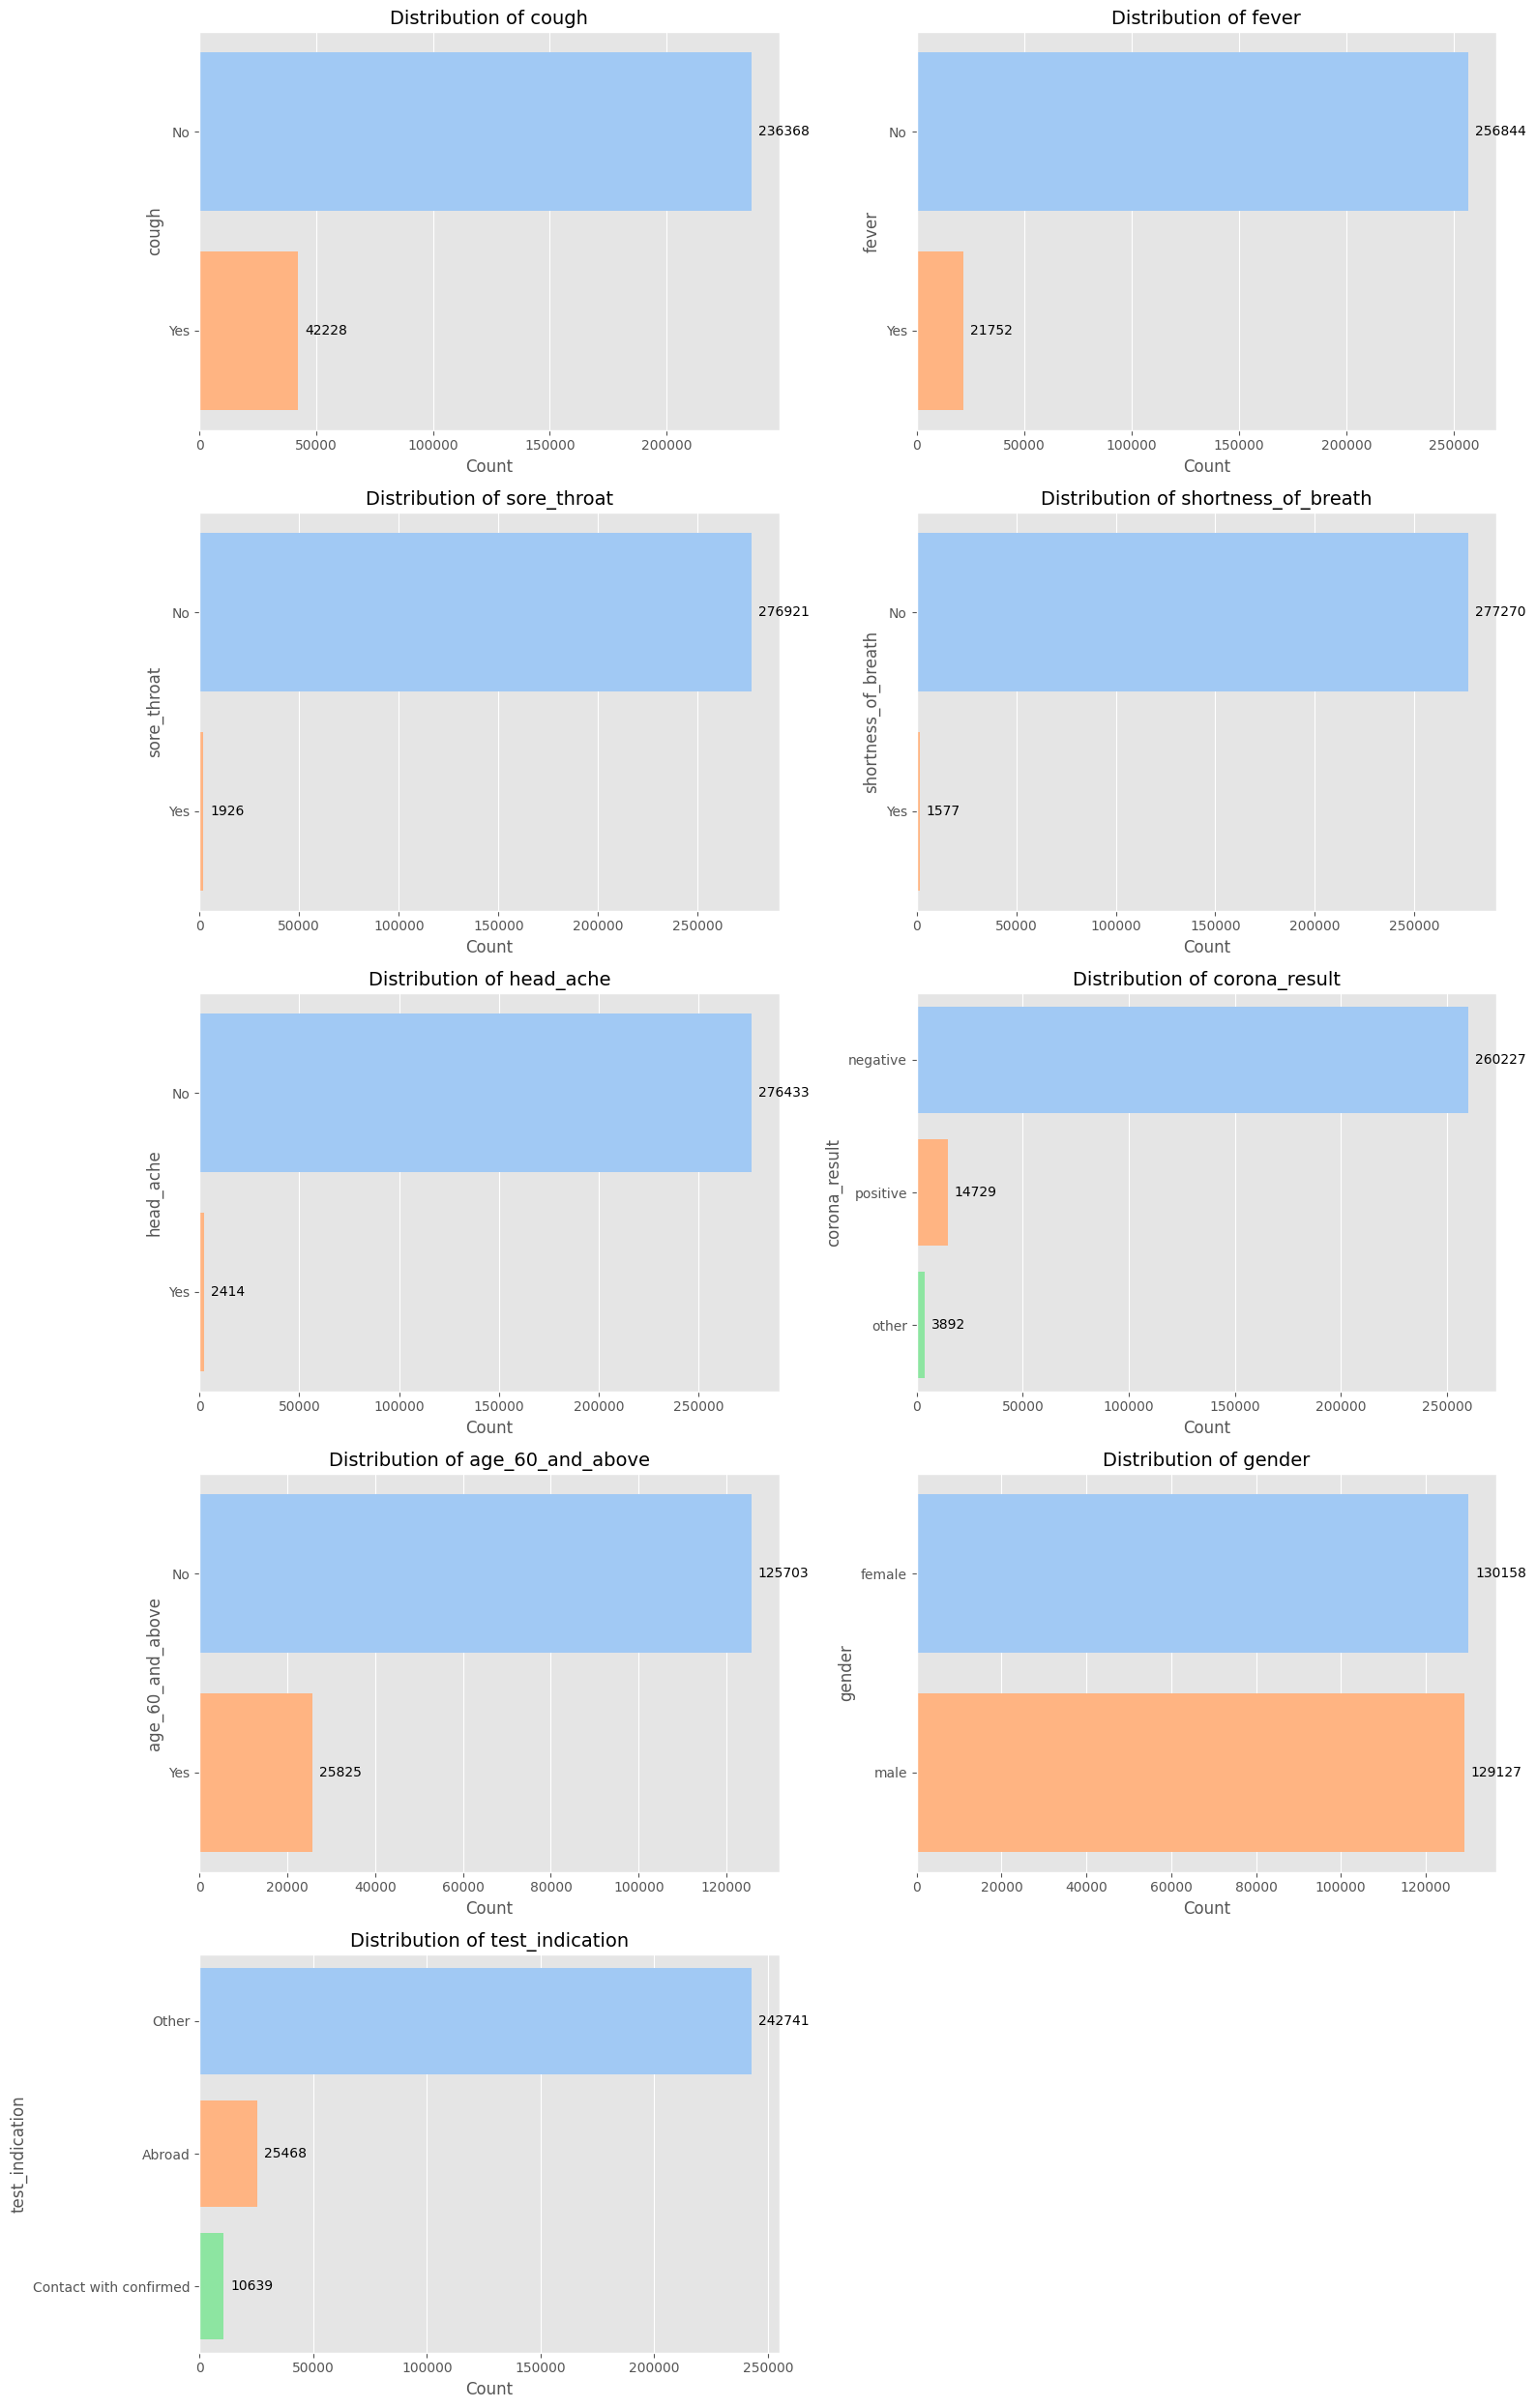

In [13]:
# Visualization of categorical columns

# Set the base color palette
palette_base = "pastel"

# Calculate the number of rows for subplots dynamically
num_cols = 2  # Number of columns for the grid layout
num_rows = (len(categorical_EDA) + num_cols - 1) // num_cols  # Round up to fit all variables

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(16, 5 * num_rows))
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Iterate over categorical columns and plot
for idx, (col, ax) in enumerate(zip(categorical_EDA, axes)):
    # Get unique categories and their counts
    unique_categories = data[col].value_counts().index
    num_categories = len(unique_categories)

    # Generate a custom color palette for the column
    colors = sns.color_palette(palette_base, n_colors=num_categories)
    color_mapping = dict(zip(unique_categories, colors))

    # Create the countplot
    sns.countplot(data=data, y=col, ax=ax, order=unique_categories)
    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_ylabel(col, fontsize=12)  # Set y-axis label
    ax.set_xlabel('Count', fontsize=12)  # Set x-axis label

    # Add custom colors to the bars
    for p, category in zip(ax.patches, unique_categories):
        p.set_facecolor(color_mapping[category])

    # Add annotations to the bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{int(width)}',
                    xy=(width, p.get_y() + p.get_height() / 2),
                    xytext=(5, 0),
                    textcoords='offset points',
                    ha='left', va='center', fontsize=10)

# Hide any unused subplots
for ax in axes[len(categorical_EDA):]:
    ax.axis("off")  # Turn off unused subplots

# Adjust layout and display
plt.tight_layout()
plt.show()

## **Data Preparation**

**Data Cleaning**

### **Missing Values Assesment**

In [14]:
# Missing values check
pd.DataFrame({
    'missing values': data.isnull().sum(),
    'percentage of missing values': data.isnull().sum() *100 / len(data)
})

,missing values,percentage of missing values
test_date,0,0.000000
cough,252,0.090372
fever,252,0.090372
sore_throat,1,0.000359
shortness_of_breath,1,0.000359
head_ache,1,0.000359
corona_result,0,0.000000
age_60_and_above,127320,45.659284
gender,19563,7.015650
test_indication,0,0.000000


**Reviewing missing values relationship between features**

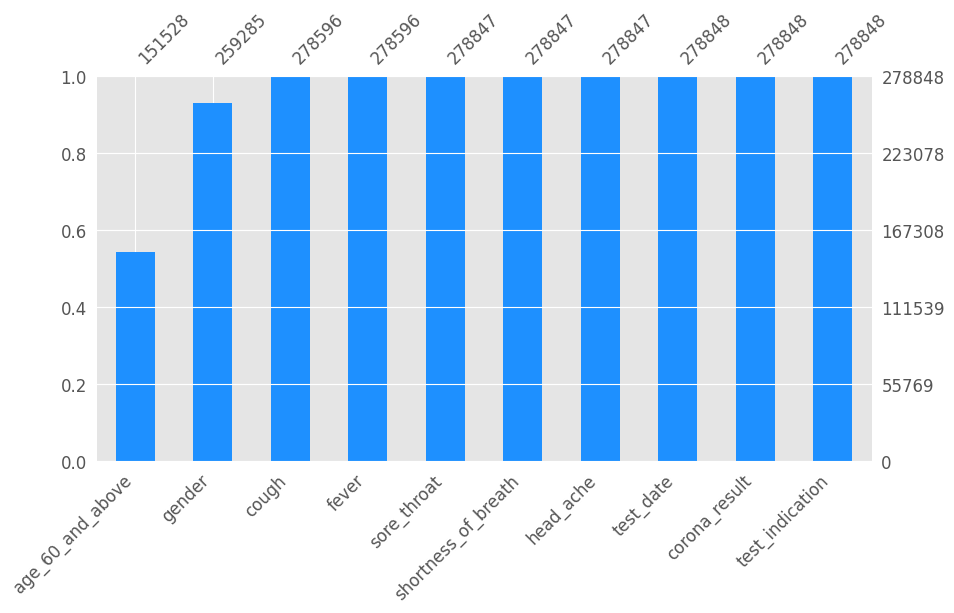

In [15]:
msno.bar(data,color="dodgerblue", sort="ascending", figsize=(10,5), fontsize=12)
plt.show()

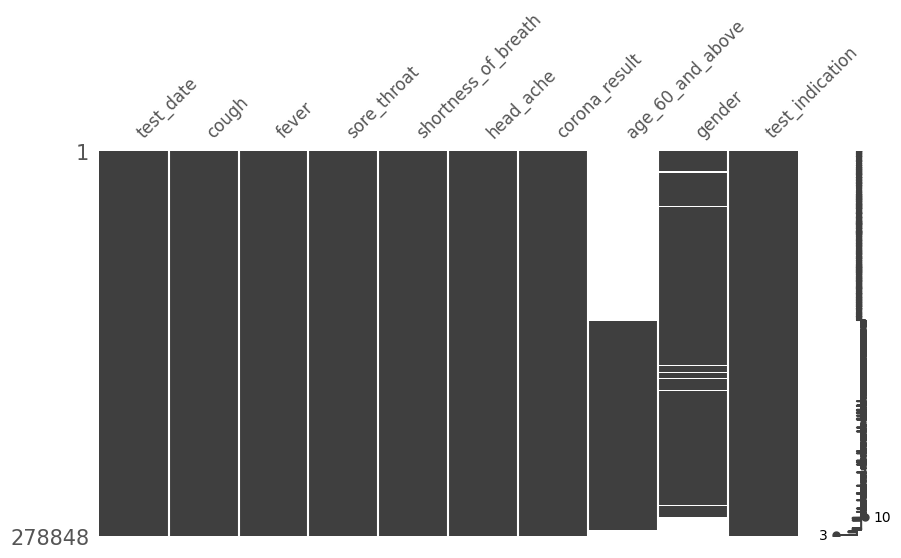

In [16]:
msno.matrix(data, figsize=(10,5), fontsize=12)
plt.show()

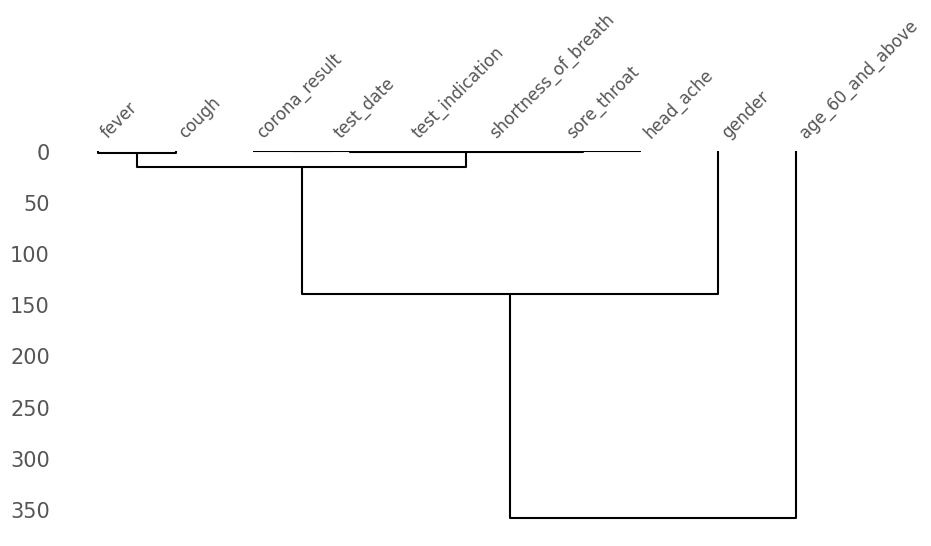

In [17]:
msno.dendrogram(data, figsize=(10,5), fontsize=12)
plt.show()

**Data Cleaning**

After knowing the number and percentage of missing values, We decide to handle the differently.


* We will drop columns of `test_date`, since this column do not contribute to prediction
* `Cough`, `fever`, `sore_throat`, `shortness_of_breath`, `head_ache` have very small percentage of missing values (less than 1%). We decided to drop them.
* `gender` column has ≈7% of missing values. We will impute them with a label like 'unknown'
* `age_60_and_above` contains more that 45.66% of missing values. This is very high. We will impute them with new label as `age60_missing`


**Dropping unnecessary columns and category**

In [18]:
# Deleting the 'test_date' column
data = data.drop(columns=["test_date"])

In [19]:
data.shape

(278848, 9)

In [20]:
# Deleting the category of 'other' in corona_result
data = data[data['corona_result'] != 'other']
data.shape

(274956, 9)

**Handling missing values**

In [21]:
# Drop missing values
# Missing values of these column below less than 1%
data = data.dropna(subset=['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache'])

In [22]:
# Impute `gender` column with `unknown
from sklearn.impute import SimpleImputer
symptom_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

# Transform the column and assign back
data['gender'] = symptom_imputer.fit_transform(data[['gender']])[:, 0]

In [23]:
# Impute `age_60_and_above` with `age_missing`
age_imputer = SimpleImputer(strategy='constant', fill_value='age_missing')
data['age_60_and_above'] = age_imputer.fit_transform(data[['age_60_and_above']])[:, 0]

In [24]:
# Missing values # sanity check
pd.DataFrame({
    'missing values': data.isnull().sum(),
    'percentage of missing values': data.isnull().sum() *100 / len(data)
})

,missing values,percentage of missing values
cough,0,0.0
fever,0,0.0
sore_throat,0,0.0
shortness_of_breath,0,0.0
head_ache,0,0.0
corona_result,0,0.0
age_60_and_above,0,0.0
gender,0,0.0
test_indication,0,0.0


In [25]:
data.dtypes.to_frame('data types')

,data types
cough,object
fever,object
sore_throat,object
shortness_of_breath,object
head_ache,object
corona_result,object
age_60_and_above,object
gender,object
test_indication,object


**Multicolinearity check**

In [26]:
# Defining variance inflation factors
def calculate_vif(data):
    vif = pd.DataFrame()
    vif['Feature'] = data.columns
    vif['VIF'] = [variance_inflation_factor(data.dropna(), i) for i in range(len(data.columns))]

    return vif.sort_values('VIF', ascending=False)

In [27]:
vif_df = calculate_vif(data[numerical])
dropped_columns = []

for i in range(len(vif_df)):
    if vif_df.iloc[0, -1] < 10:
        break
    else:
        dropped_columns.append(vif_df.iloc[0, 0])
        vif_df = calculate_vif(data[numerical].drop(columns=dropped_columns))

In [28]:
vif_df # No Numerical

,Feature,VIF


In [29]:
dropped_columns

[]

### **Cardinality Check**

In [30]:
# Checking cardinality

# creating a function to check cardinality
def check_cardinality(data):
    cardinality_info = []

    for feature in data.select_dtypes(include='object').columns:
        cardinality = len(data[feature].unique())
        warning = "High" if cardinality > 10 else "Low"
        cardinality_info.append({'Feature': feature, 'Cardinality': cardinality, 'Warning': warning})

    return pd.DataFrame(cardinality_info)

cardinality_data = check_cardinality(data)
cardinality_data

,Feature,Cardinality,Warning
0,cough,2,Low
1,fever,2,Low
2,sore_throat,2,Low
3,shortness_of_breath,2,Low
4,head_ache,2,Low
5,corona_result,2,Low
6,age_60_and_above,3,Low
7,gender,3,Low
8,test_indication,3,Low


### **Imbalance Data Assesment**

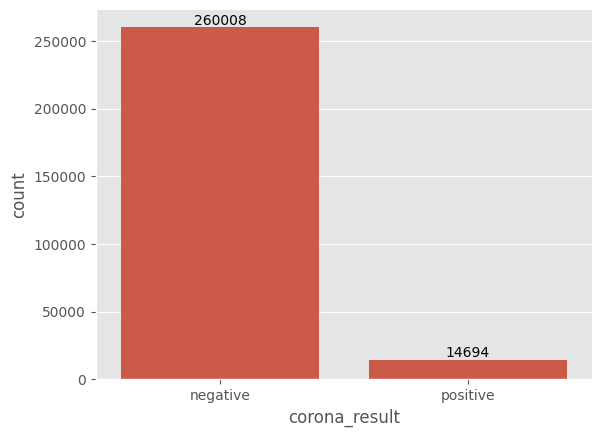

In [31]:
# imbalanced data check
ax = sns.countplot(data, x="corona_result")
for label in ax.containers:
    ax.bar_label(label)
sns.despine()
plt.show()

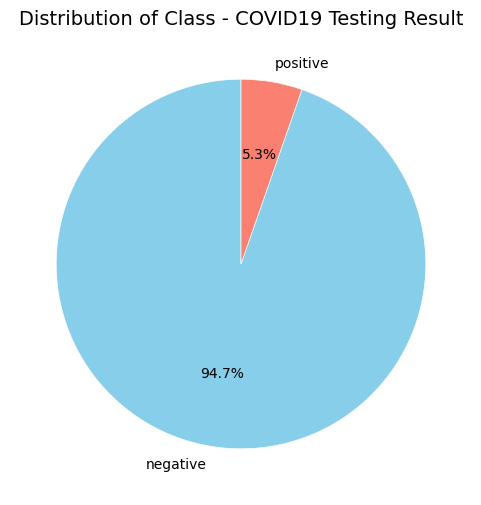

In [33]:
# Count the occurrences of each class
data_counts = data["corona_result"].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    data_counts,
    labels=data_counts.index,
    autopct='%1.1f%%',      # show percentages
    startangle=90,          
    colors=['skyblue', 'salmon'],  
    wedgeprops={'edgecolor': 'white'}  # clean border
)

# Add title
plt.title("Distribution of Class - COVID19 Testing Result", fontsize=14)
plt.show()

In [230]:
# Imbalance data check
data["corona_result"].value_counts()

# Imbalance data check
data["corona_result"].value_counts(normalize=True)

corona_result
negative    0.946509
positive    0.053491
Name: proportion, dtype: float64

The dataset is highly imbalanced.

In [231]:
# Creating function for plotting categorical features
def create_plot(data, col, x_maks=1000):

    agg_table = data.groupby([col, 'corona_result']).size().unstack().reset_index()
    agg_table['total'] = agg_table['positive']+agg_table['negative']
    agg_table['% positive'] = (agg_table['positive']/agg_table['total']*100).round(2)
    agg_table = agg_table.sort_values(by='% positive', ascending=False)
    agg_table

    fig, axes = plt.subplots(1, 2, figsize=(16,5))

    ax1 = sns.barplot(data=agg_table, y=col, x='% positive', ax=axes[0])
    label = ['{:.1f} %'.format(x) for x in ax1.containers[0].datavalues]
    ax1.bar_label(ax1.containers[0], labels=label, padding=3, label_type='center')
    ax1.set_title(f'Percentage of getting sick by COVID19 by {col}')

    ax2 = sns.countplot(data=data, y=col, hue='corona_result', order=agg_table[col], ax=axes[1])
    ax2.set_title(f'Number of patient getting sick by COVID19 according to {col}')
    for container in ax2.containers:
        ax2.bar_label(container)
    ax2.set_xlim(0, x_maks)

    plt.tight_layout()
    plt.show()

In [232]:
data.columns

Index(['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'corona_result', 'age_60_and_above', 'gender', 'test_indication'],
      dtype='object')

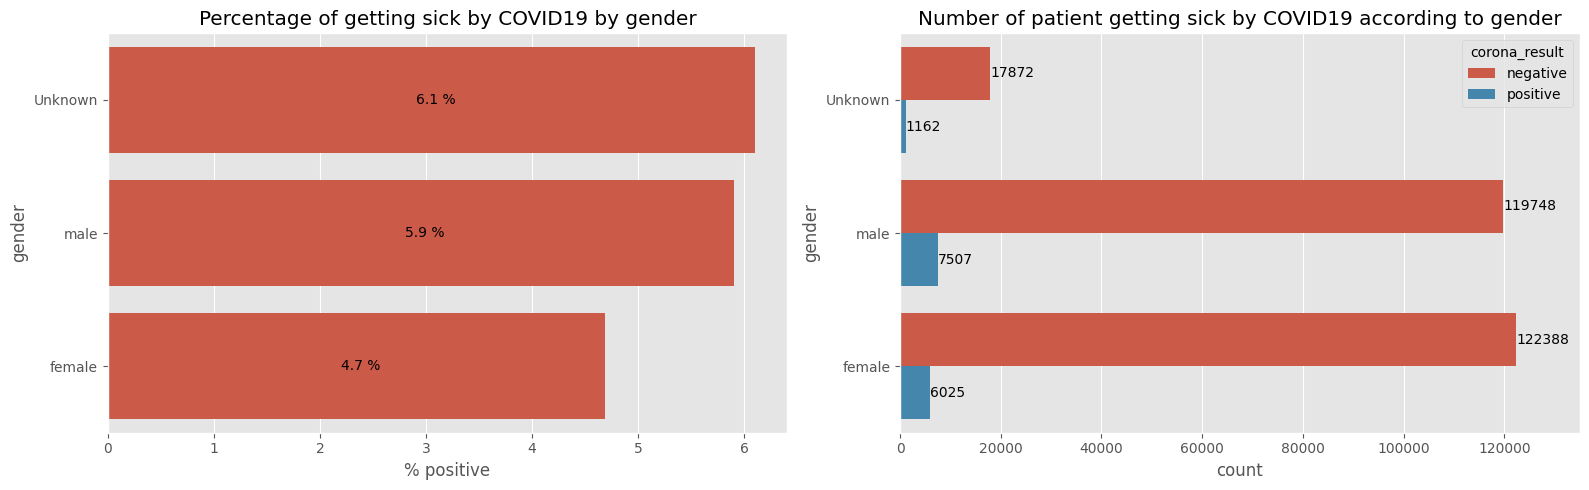

In [233]:
# Percentage and number of COVID19 positive result by 'gender'
create_plot(data, 'gender', x_maks=135000)

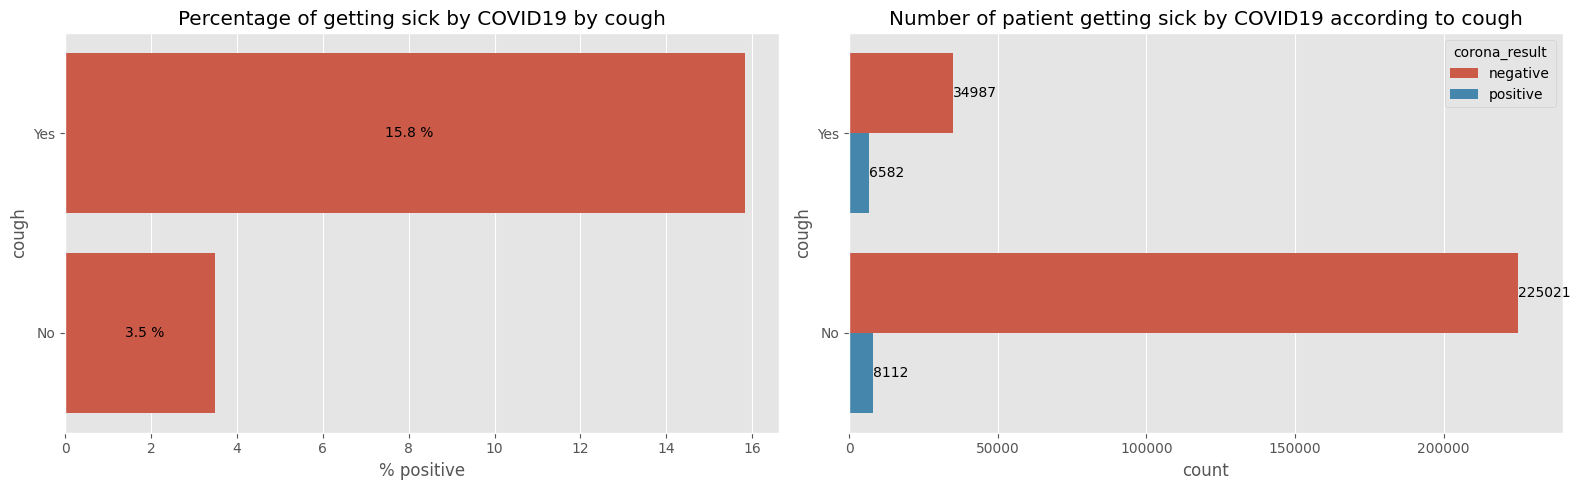

In [234]:
# Percentage and number of COVID19 positive result by 'cough'
create_plot(data, 'cough', x_maks=240000)

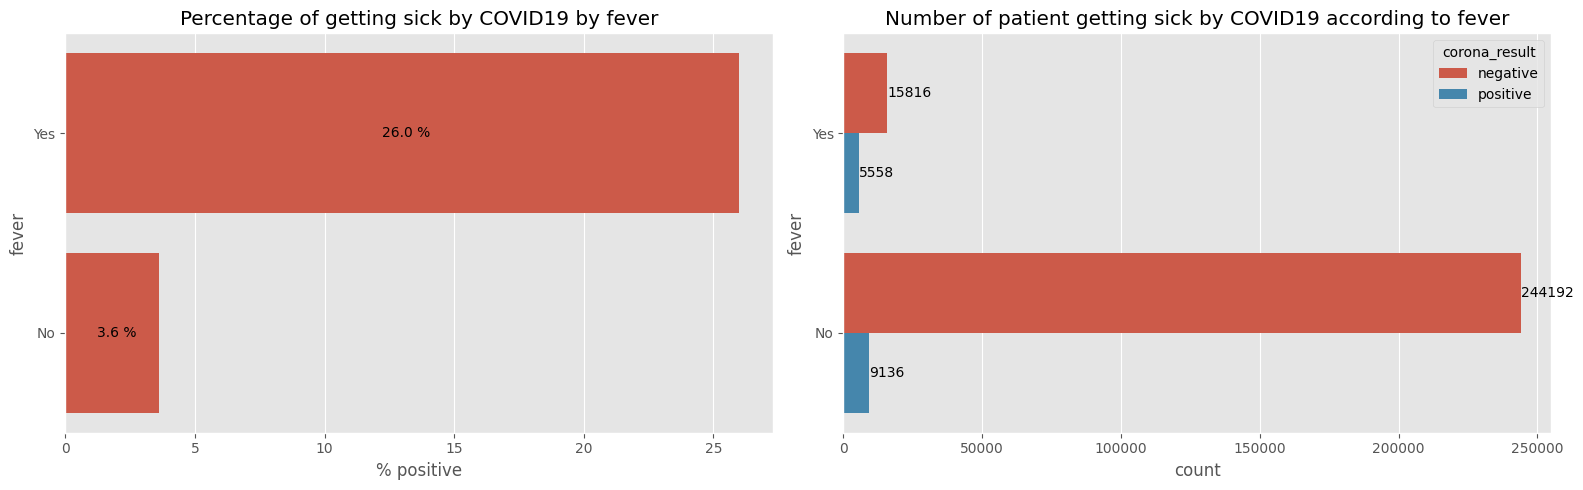

In [235]:
# Percentage and number of COVID19 positive result by 'fever'
create_plot(data, 'fever', x_maks=255000)

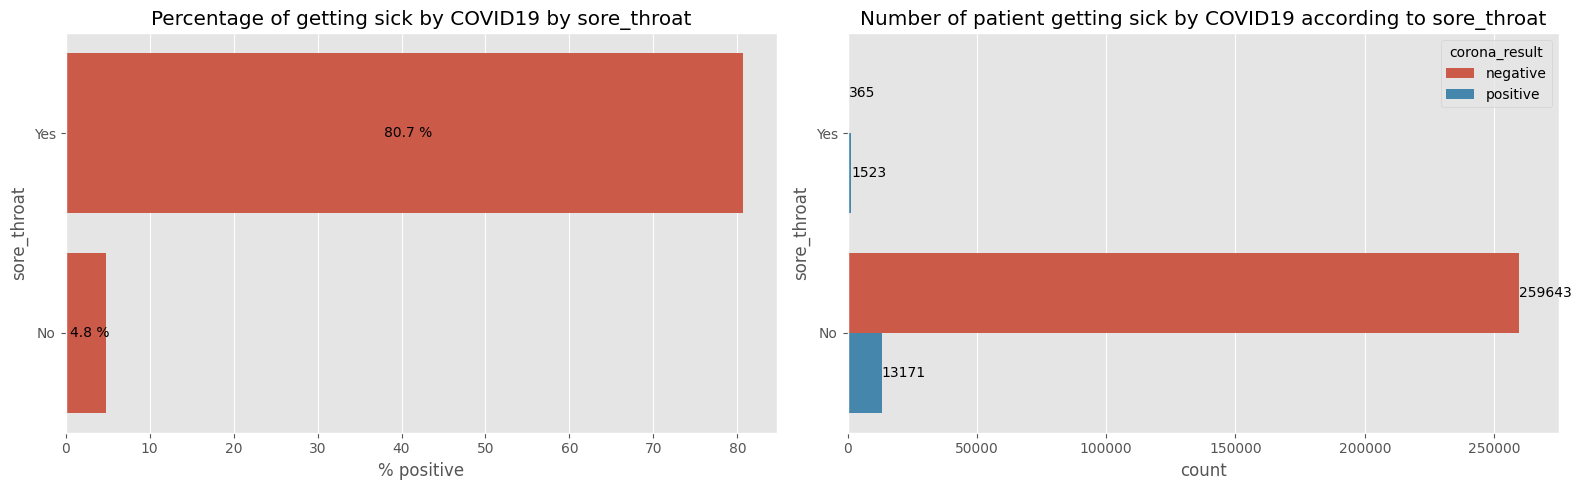

In [236]:
# Percentage and number of COVID19 positive result by 'sore_throat'
create_plot(data, 'sore_throat', x_maks=275000)

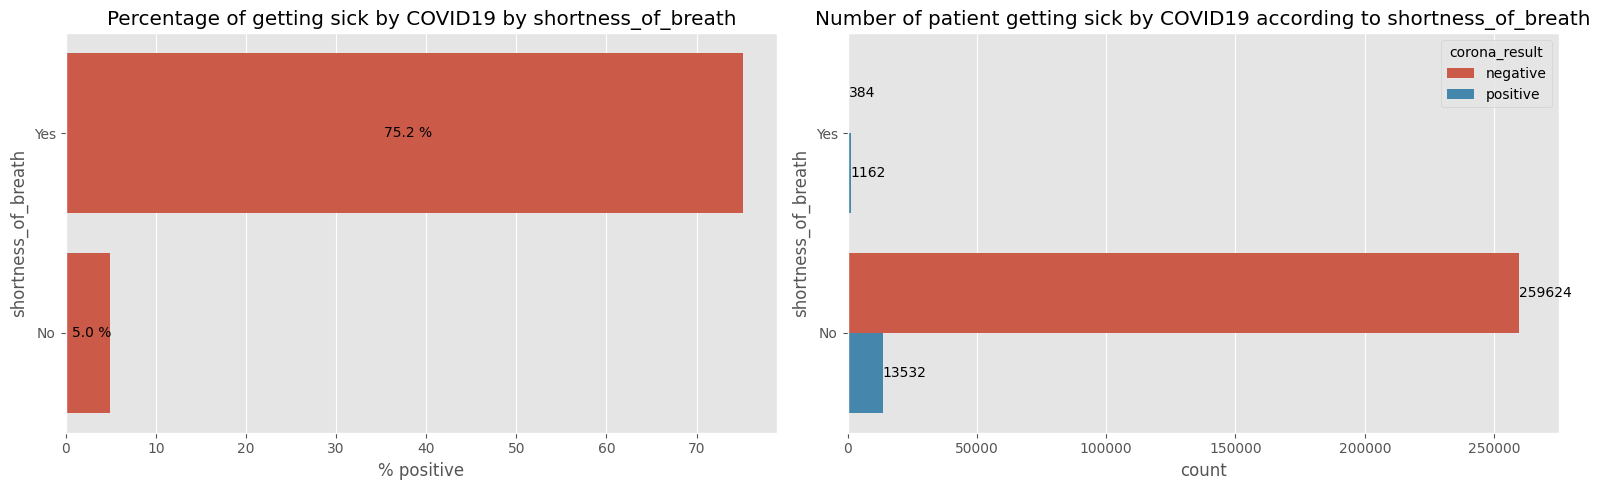

In [237]:
# Percentage and number of COVID19 positive result by 'shortness_of_breath'
create_plot(data, 'shortness_of_breath', x_maks=275000)

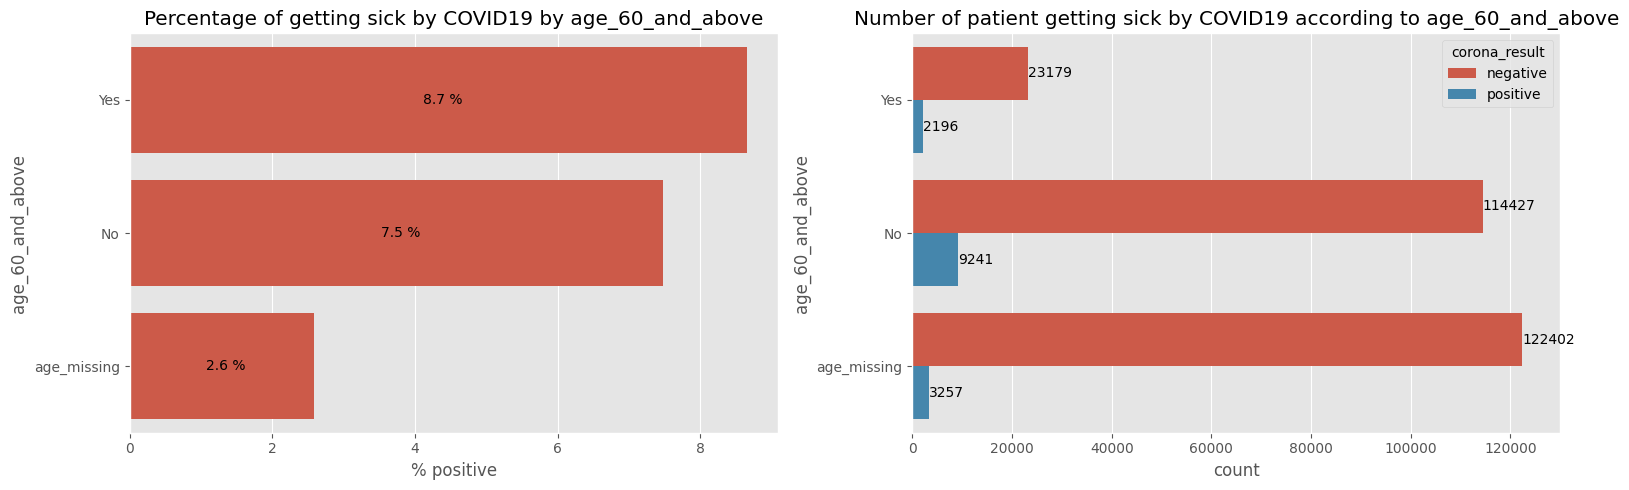

In [238]:
# Percentage and number of COVID19 positive result by 'age_60_and_above'
create_plot(data, 'age_60_and_above', x_maks=130000)

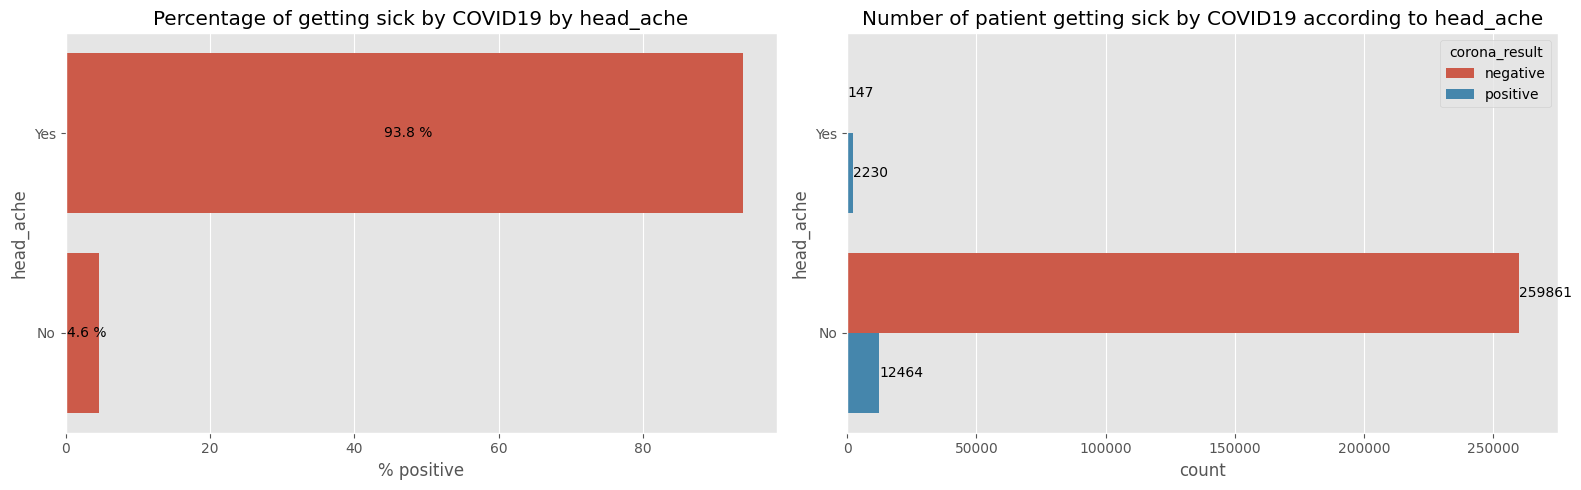

In [239]:
# Percentage and number of COVID19 positive result by 'head_ache'
create_plot(data, 'head_ache', x_maks=275000)

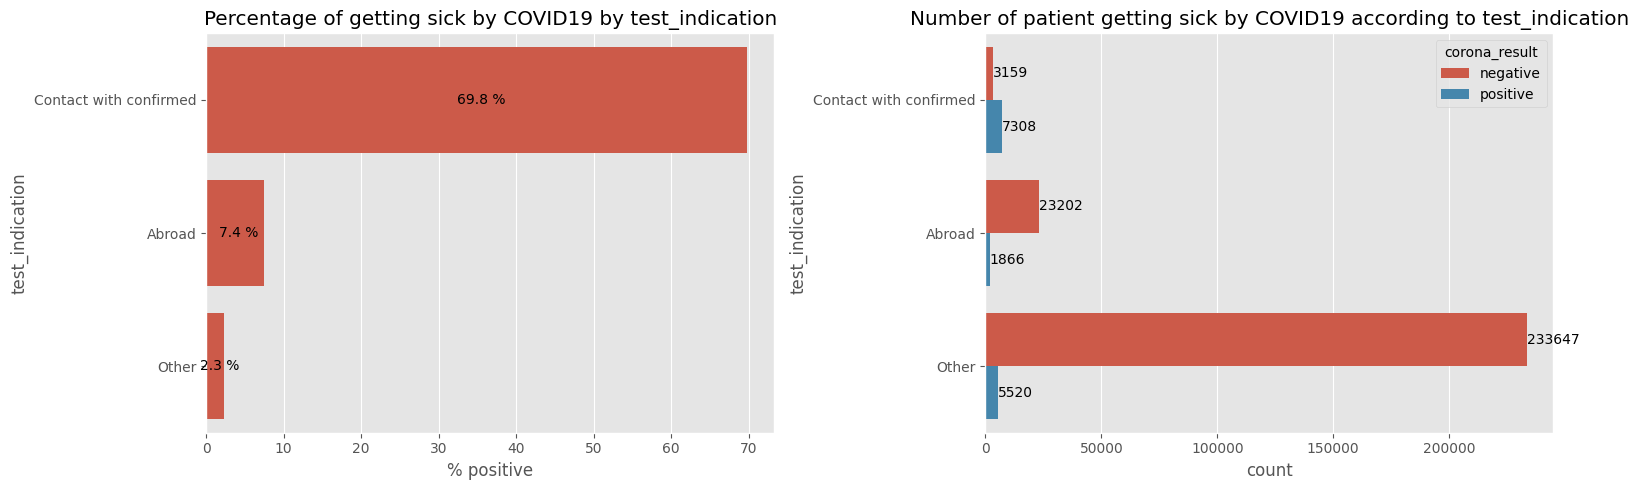

In [240]:
# Percentage and number of COVID19 positive result by 'test_indication'
create_plot(data, 'test_indication', x_maks=245000)

### **Data Analysis - Features vs Target**

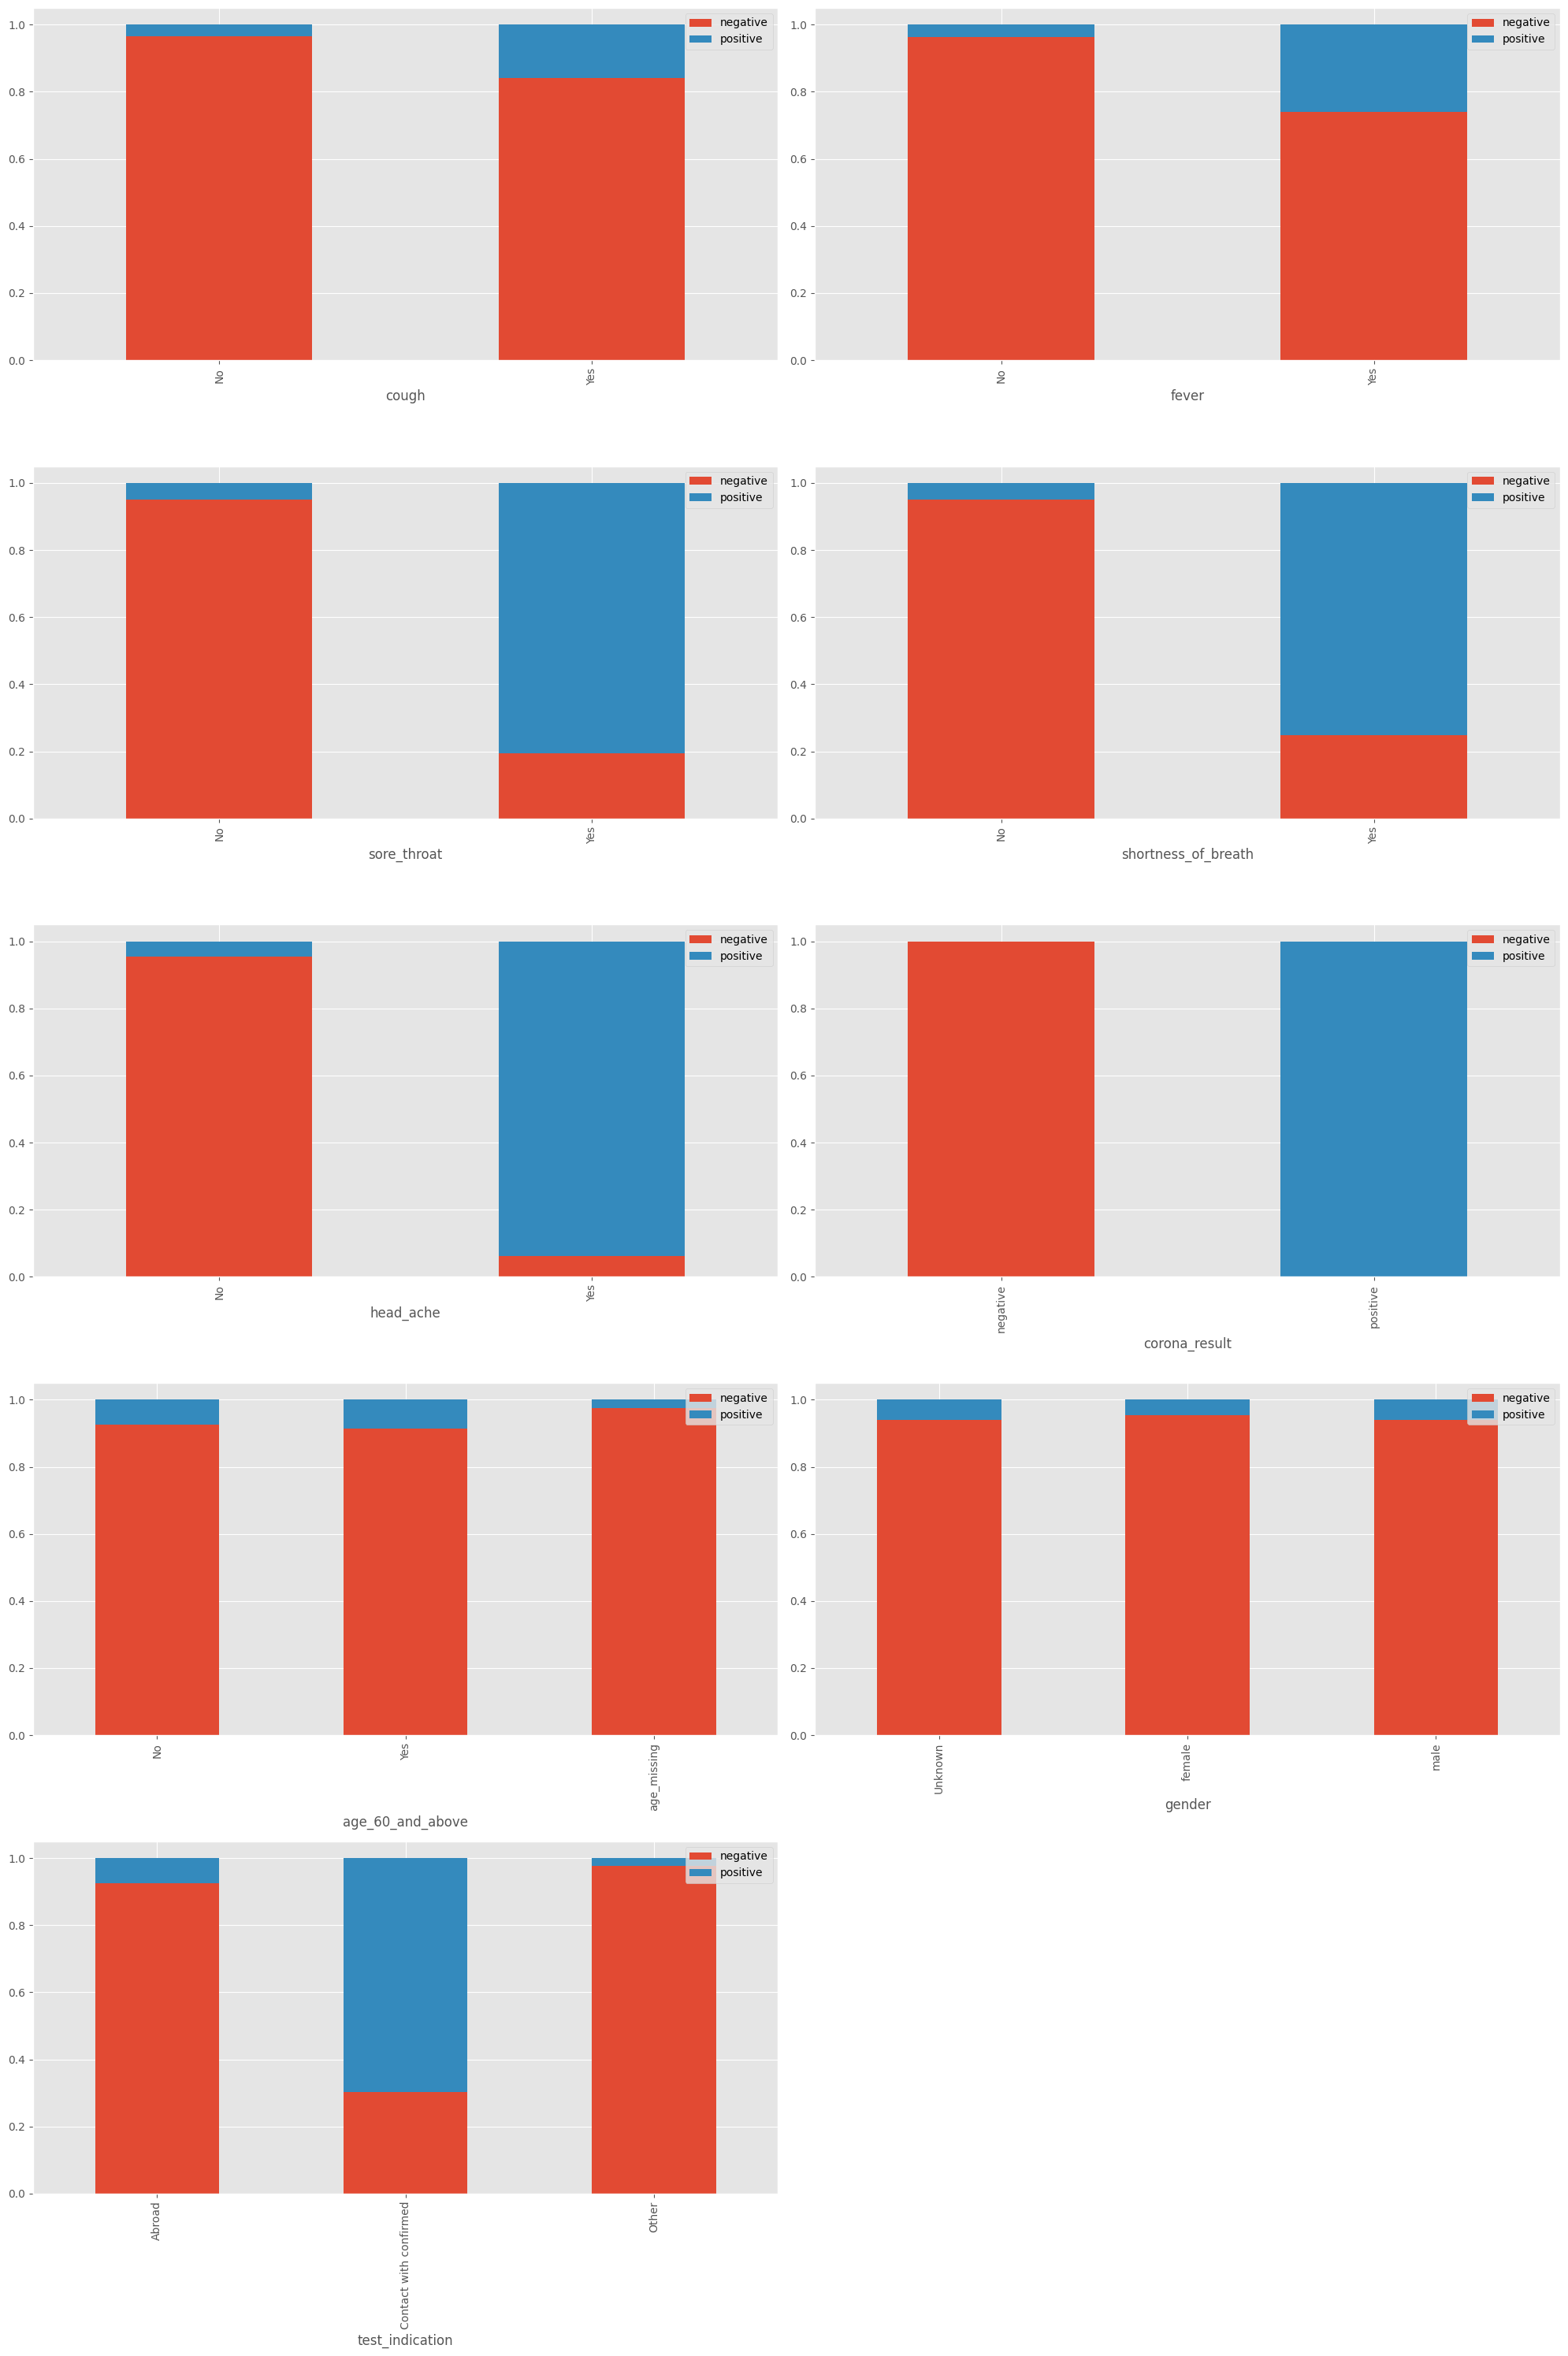

In [241]:
# Visualizing claim proportion of categorical features
count = 0
fig = plt.figure(figsize=(20,30))

for i in data.columns:
    count += 1
    ax = plt.subplot(5, 2, count)
    pd.crosstab(data[i], data['corona_result'], normalize=0).plot(kind='bar', stacked=True, ax=ax)
    ax.legend(loc='upper right')  # Position the legend in the upper right corner
    fig.tight_layout()

plt.show()

In [242]:
# Percentage of features vs target
# Table of categorical feature vs target (class)
for col in data.drop(columns=['corona_result']).columns:
    # Get the count of each class per categorical feature
    count_data = data.groupby([col, 'corona_result']).size().unstack(fill_value=0)

    # Normalize the counts to get proportions
    normalized_data = round((count_data.div(count_data.sum(axis=1), axis=0)),3)

    # Display the sorted values
    display(normalized_data.sort_values(by=['positive'], ascending=False))

corona_result,negative,positive
cough,,
Yes,0.842,0.158
No,0.965,0.035


corona_result,negative,positive
fever,,
Yes,0.740,0.260
No,0.964,0.036


corona_result,negative,positive
sore_throat,,
Yes,0.193,0.807
No,0.952,0.048


corona_result,negative,positive
shortness_of_breath,,
Yes,0.248,0.752
No,0.950,0.050


corona_result,negative,positive
head_ache,,
Yes,0.062,0.938
No,0.954,0.046


corona_result,negative,positive
age_60_and_above,,
Yes,0.913,0.087
No,0.925,0.075
age_missing,0.974,0.026


corona_result,negative,positive
gender,,
Unknown,0.939,0.061
male,0.941,0.059
female,0.953,0.047


corona_result,negative,positive
test_indication,,
Contact with confirmed,0.302,0.698
Abroad,0.926,0.074
Other,0.977,0.023


**Key Insights**

In general, we divide the present features into 3 distinct categories such as symptoms, demographics, and exposure history. The insights from features can be seen below

**Symptoms strongly correlate with positive results**

* Individuals showing headache (93.8%), sore throat (80.7%), or shortness of breath (75.2%) have a much higher likelihood of testing positive than those without these symptoms.
* Fever (26%) and cough (15.8%) also show positive association, though to a lesser extent.



**Demographics: Age and gender show limited effect**

* Older adults (60+) have a slightly higher positivity rate (8.7%) than younger individuals (7.5%).
* Gender differences are minimal, with males (5.9%) and females (4.7%) showing comparable results.

**Exposure history (test indication) with infection risk**

* People who had contact with confirmed cases have the highest positive rate (69.8%), making this the strongest single predictor.
* In contrast, “Abroad” (7.4%) and “Other” (2.3%) categories show very low positivity.

## **Model Building**

**Replacing values**

In [243]:
data['corona_result'] = np.where(data['corona_result']=='positive',1,0)

**Define features and target**

In [244]:
# define features and target
X = data.drop(columns=['corona_result'])
y = data['corona_result']

In [245]:
X.columns

Index(['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication'],
      dtype='object')

**Data splitting**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

**Feature engineering**

In [ ]:
# Column Transformer
transformer = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication']),
], remainder='passthrough')

**Scaling**

In [ ]:
# Scaling

# maxabscaler # Handling sparse data
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()

**Resamplers - Handling imbalance**

In [ ]:
# Handling imbalance

# SMOTENC
categorical_cols = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication']

# Get their indices from the dataframe
categorical_indices = [X.columns.get_loc(c) for c in categorical_cols]

# Define SMOTENC
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=0)


**Pipeline**

In [ ]:
# Pipeline
Pipeline([
    ('transformer', transformer),
    ('scaler', scaler),
    ('resamplers', smotenc)
])

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['cough', 'fever',
                                                   'sore_throat',
                                                   'shortness_of_breath',
                                                   'head_ache',
                                                   'age_60_and_above', 'gender',
                                                   'test_indication'])])),
                ('scaler', MaxAbsScaler()),
                ('resamplers',
                 SMOTENC(categorical_features=[0, 1, 2, 3, 4, 5, 6, 7],
                         random_state=0))])

### **Cross validation**

In [ ]:
# Cross validation
# Stratified cross validation
skf = StratifiedKFold(n_splits = 5)

### **Model benchmarking**

To identify the most effective classification model, we developed and evaluated eight machine learning algorithms using their default (basic) parameters. This benchmarking process aims to compare performance across different model families, including both base learners and ensemble methods.

The tested algorithms include:

Base Models:

* Logistic Regression — a linear model that estimates class probabilities based on a logistic function.

* K-Nearest Neighbors (KNN) — a distance-based model that classifies samples according to the majority label of their nearest neighbors.

* Decision Tree — a non-linear model that splits data recursively based on feature importance to form decision rules.

Ensemble Models:

* Bagging Method:

    * Random Forest — an ensemble of decision trees trained on different subsets of data to reduce variance and improve generalization.

* Boosting Methods:

    * AdaBoost — combines weak learners sequentially, where each new model focuses more on previously misclassified samples.

    * Gradient Boosting (GradBoost) — builds models sequentially by minimizing the residual error using gradient descent.

    * XGBoost — an optimized implementation of gradient boosting that improves computational speed and model regularization.

    * LightGBM (LGBM) — a gradient boosting framework that uses a leaf-wise tree growth algorithm for faster training and better accuracy with large datasets.

In [ ]:
# Machine Learning/Algorithmic models
logreg = LogisticRegression(random_state=0)
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
ada = AdaBoostClassifier(random_state=0)
grad = GradientBoostingClassifier(random_state=0)
xgb = XGBClassifier(random_state=0)
lgbm = LGBMClassifier(random_state=0)

### **Training and Validation Set**

In [ ]:
# Recall # Model training

# 9 Models selection
models = {
    "logreg": logreg,
    "knn": knn,
    "dtree": dtree,
    "rf": rf,
    "ada": ada,
    "grad": grad,
    "xgb": xgb,
    "lgbm": lgbm
}


# models that need scaling
needs_scaling = ["logreg", "knn"]

# storage for results
recall_mean_with_smotenc = []
recall_std_with_smotenc = []

for name, model in tqdm(models.items(), desc="Running models", unit="model"):

    # -------------------
    # Pipeline with SMOTENC
    # -------------------
    steps = [('prep', transformer)]
    if name in needs_scaling:
        steps.append(('scaler', scaler))
    steps.append(('resample', smotenc))
    steps.append(('algo', clone(model)))
    pipe_model_with_smotenc = Pipeline(steps)

    model_cv_with_smotenc = cross_val_score(
        estimator=pipe_model_with_smotenc,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring='recall',
        n_jobs=-1
    )
    mean_smotenc = model_cv_with_smotenc.mean()
    std_smotenc = model_cv_with_smotenc.std()
    recall_mean_with_smotenc.append(mean_smotenc)
    recall_std_with_smotenc.append(std_smotenc)

    tqdm.write(f"[{name}] → Recall: {mean_smotenc:.4f} ± {std_smotenc:.4f}")



Running models:  12%|█▎        | 1/8 [02:12<15:27, 132.57s/model]

[logreg] → Recall: 0.7532 ± 0.0076


Running models:  25%|██▌       | 2/8 [1:17:15<4:30:21, 2703.57s/model]

[knn] → Recall: 0.7848 ± 0.0161


Running models:  38%|███▊      | 3/8 [1:19:05<2:06:36, 1519.23s/model]

...

[grad] → Recall: 0.7954 ± 0.0078


Running models:  88%|████████▊ | 7/8 [1:32:52<06:53, 413.65s/model]

[xgb] → Recall: 0.7989 ± 0.0072


Running models: 100%|██████████| 8/8 [1:35:05<00:00, 713.23s/model]

[lgbm] → Recall: 0.7973 ± 0.0051


In [ ]:
pd.DataFrame({
    'model' : ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'GradienBoost', 'XGBoost', 'LightGBM'],
    'recall_mean_with_smotenc' : recall_mean_with_smotenc,
    'recall_std_with_smotenc' : recall_std_with_smotenc,
}).sort_values('recall_mean_with_smotenc', ascending=False)

,model,recall_mean_with_smotenc,recall_std_with_smotenc
6,XGBoost,0.798894,0.007225
7,LightGBM,0.797278,0.005123
3,Random Forest,0.795406,0.005265
5,GradienBoost,0.795406,0.007764
2,Decision Tree,0.792514,0.005240
1,KNN,0.784772,0.016056
4,AdaBoost,0.758911,0.005828
0,Logistic Regression,0.753211,0.007606


### **Testing set**

In [ ]:
# Predicting to test data


# 9 Models selection
models = {
    "logreg": logreg,
    "knn": knn,
    "dtree": dtree,
    "rf": rf,
    "ada": ada,
    "grad": grad,
    "xgb": xgb,
    "lgbm": lgbm
}

# models that need scaling
needs_scaling = ["logreg", "knn"]

# storage for results
mean_recall_test = []
roc_auc_scores = []

# Find the best model

for name, model in tqdm(models.items(), desc="Running models", unit="model"):


    # -------------------
    # Pipeline (with SMOTENC)
    # -------------------
    steps = [('prep', transformer)]
    if name in needs_scaling:
        steps.append(('scaler', scaler))
    steps.append(('resample', smotenc))
    steps.append(('algo', clone(model)))
    model_pipe = Pipeline(steps)

    # fit the model
    model_pipe.fit(X_train, y_train)

    # predict on test set
    y_pred = model_pipe.predict(X_test)
    y_pred_proba = model_pipe.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC

    # evaluate recall
    score = recall_score(y_test, y_pred)
    mean_recall_test.append(score)

    # evaluate ROC-AUC score
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    roc_auc_scores.append(roc_auc)

    #tqdm.write(f"[{name}] → Recall: {mean_recall_test:.4f} | ROC AUC: {roc_auc_scores:.4f}")
    tqdm.write(f"[{name}] → Recall: {score:.4f} | ROC AUC: {roc_auc:.4f}")


Running models:  12%|█▎        | 1/8 [00:45<05:17, 45.36s/model]

[logreg] → Recall: 0.7400 | ROC AUC: 0.8919


Running models:  25%|██▌       | 2/8 [44:43<2:37:03, 1570.63s/model]

[knn] → Recall: 0.7853 | ROC AUC: 0.8746


Running models:  38%|███▊      | 3/8 [45:34<1:13:02, 876.47s/model] 

...

[grad] → Recall: 0.7788 | ROC AUC: 0.9008


Running models:  88%|████████▊ | 7/8 [51:46<03:38, 218.69s/model]

[xgb] → Recall: 0.7894 | ROC AUC: 0.9017
[LightGBM] [Info] Number of positive: 208006, number of negative: 208006
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 416012, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Running models: 100%|██████████| 8/8 [52:38<00:00, 394.79s/model]

[lgbm] → Recall: 0.7890 | ROC AUC: 0.9024


In [ ]:
# Model performance comparison
pd.DataFrame({
    'model' : ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'AdaBoost', 'GradienBoost', 'XGBoost', 'LightGBM'],
    'Mean recall - training set': recall_mean_with_smotenc, #smotenc
    'Mean recall - testing set': mean_recall_test
}).sort_values('Mean recall - testing set', ascending=False)

,model,Mean recall - training set,Mean recall - testing set
6,XGBoost,0.798894,0.789384
7,LightGBM,0.797278,0.789044
3,Random Forest,0.795406,0.786662
1,KNN,0.784772,0.785301
2,Decision Tree,0.792514,0.783600
5,GradienBoost,0.795406,0.778836
4,AdaBoost,0.758911,0.748554
0,Logistic Regression,0.753211,0.740048


**Insights**

Based on the result above, we can provide general observations:
* Ensemble tree-based models (XGBoost, LightGBM, Random Forest) dominate recall performance.
* Boosting methods (XGBoost, LightGBM) slightly outperform bagging (Random Forest), showing they capture minority class patterns better.
* Models like AdaBoost and Logistic Regression show lower recall, suggesting those models relatively underfitting or poor handling of class imbalance.


### **Hyperparameter tunning**

#### **XGBoost**

In [ ]:
# Hyperparameter tuning Xgboost

# Preprocessing
# Column Transformer
transformer = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication']),
], remainder='passthrough')
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=0)
#smotenc = SMOTENC(random_state=0, categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8]) # SMOTE for balancing
xgb = XGBClassifier(random_state=0)  # XGBoost classifier


# Defining pipeline
estimator_xgboost = Pipeline([
    ('prep', transformer),
    ('resamplers', smotenc),
    ('model', xgb)
])

# Adjusted hyperparameter space
hyperparam_space_xgboost = [{
    'model__max_depth': [3, 5, 7, 9],  # Expanding search space
    'model__learning_rate': [0.1, 0.05, 0.01, 0.001],  # Including smaller learning rates
    'model__n_estimators': [100, 150, 200, 250],  # Higher n_estimators for lower learning rates
    'model__subsample': [0.8, 0.9, 1.0],  # Exploring subsample rates
    'model__colsample_bytree': [0.8, 0.9, 1.0],  # Exploring column sampling
    'model__gamma': [0, 0.1, 0.2, 0.5],  # Adding gamma for regularization
    'model__min_child_weight': [1, 2, 3, 4],  # Adding min_child_weight
}]

# Hyperparameter tuning using RandomizedSearchCV
tuned_xgboost = RandomizedSearchCV(
    estimator_xgboost,
    n_jobs=-1,
    param_distributions=hyperparam_space_xgboost,
    scoring='recall',
    n_iter=50,
    cv=5,  # Cross-validation folds
    random_state=0,
)

# Fitting the tuned model
tuned_xgboost.fit(X_train, y_train)

# Best recall score on training set
print(f'Recall score - training set: {tuned_xgboost.best_score_:.3f}')
print(f'Best parameters: {tuned_xgboost.best_params_}')

Recall score - training set: 0.821
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 150, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.001, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}


In [ ]:
# Model after hyperparameter tuning
tuned_model_xgboost = tuned_xgboost.best_estimator_

# Fitting model
tuned_model_xgboost.fit(X_train, y_train)

# predict on test set
y_pred_xgboost = tuned_model_xgboost.predict(X_test)
y_pred_proba_xgboost =tuned_model_xgboost.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


# Evaluate recall score on test set
test_recall_xgboost = recall_score(y_test, y_pred_xgboost)
print(f'recall score: {test_recall_xgboost:.3f}')

recall score: 0.813


In [ ]:
# classification report
print("The Classification Report of XGBoost Classifier")
print(classification_report(y_test, y_pred_xgboost))

# Confusion matrix
print('The confusion matrix of XGBoost Classifier')
print(confusion_matrix(y_test, y_pred_xgboost))

The Classification Report of XGBoost Classifier
              precision    recall  f1-score   support

           0       0.99      0.89      0.94     52002
           1       0.29      0.81      0.43      2939

    accuracy                           0.88     54941
   macro avg       0.64      0.85      0.68     54941
weighted avg       0.95      0.88      0.91     54941

The confusion matrix of XGBoost Classifier
[[46195  5807]
 [  551  2388]]


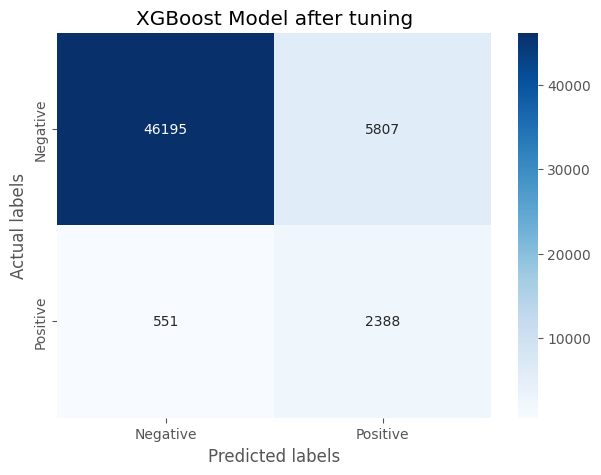

In [ ]:
# Confusion matrix visualization of XGBoost

# Setting size
plt.figure(figsize=(7,5))

# Confusion matrix # Confusion matrix heatmap visualization
ax = sns.heatmap(confusion_matrix(y_test, y_pred_xgboost),
            xticklabels=['Negative', 'Positive'],  # Custom x-axis labels
    yticklabels=['Negative', 'Positive'],   # Custom y-axis labels
    cmap='Blues',
    annot=True,
    fmt='.0f'
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('Actual labels')
plt.title('XGBoost Model after tuning')
plt.show()

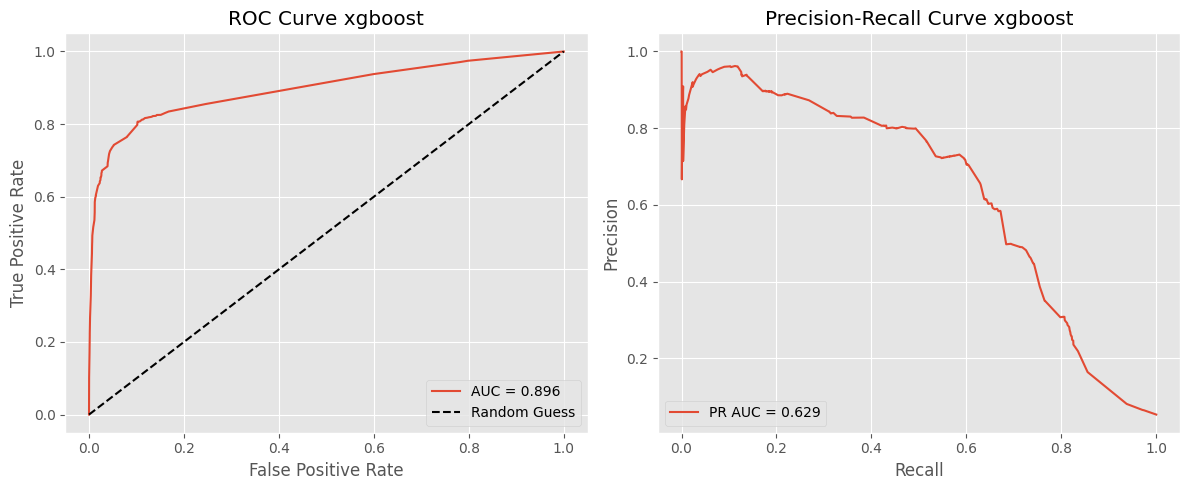

ROC-AUC Score: 0.896
PR-AUC Score: 0.629


In [ ]:
# ROC AUC vs PR AUC # xgboost


# Predictions
y_pred_proba_xgboost = tuned_model_xgboost.predict_proba(X_test)[:, 1]  # Probability of positive class

# ROC-AUC
roc_auc_xgboost = round(roc_auc_score(y_test, y_pred_proba_xgboost), 3)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgboost)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_xgboost)
pr_auc_xgboost = round(average_precision_score(y_test, y_pred_proba_xgboost), 3)

# Plot side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Generating ROC Curve
ax[0].plot(fpr, tpr, label=f"AUC = {roc_auc_xgboost}")
ax[0].plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve xgboost")
ax[0].legend(loc="lower right")

# Generating Precision-Recall Curve
ax[1].plot(recall, precision, label=f"PR AUC = {pr_auc_xgboost}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve xgboost")
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Print AUC values
print(f"ROC-AUC Score: {roc_auc_xgboost}")
print(f"PR-AUC Score: {pr_auc_xgboost}")


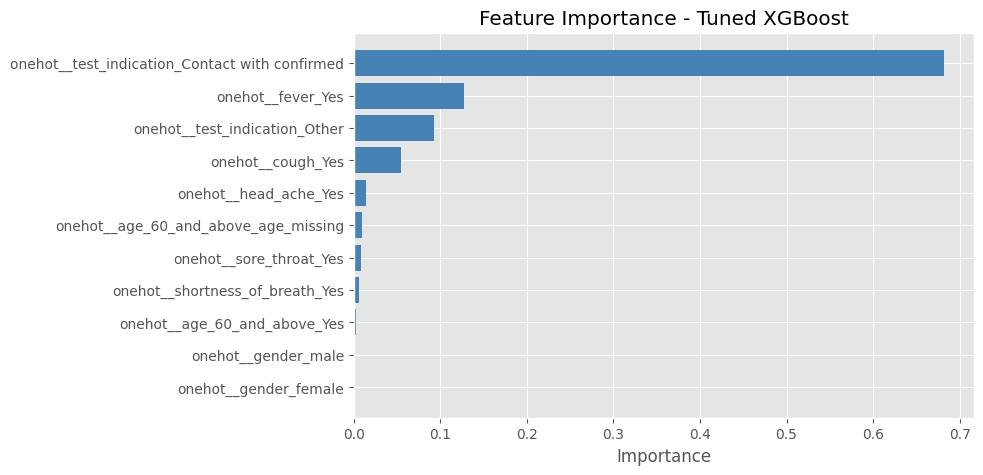

In [121]:
# Feature importance # XGBoost

# Extract fitted XGBoost model from pipeline
xgb_model = tuned_model_xgboost.named_steps['model']

# Get feature importances
importances = xgb_model.feature_importances_

# Get feature names from ColumnTransformer (after OneHotEncoder)
encoder = tuned_model_xgboost.named_steps['prep'] # 'prep' is preprocessing step
feature_names = encoder.get_feature_names_out()

# Combine into a DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - Tuned XGBoost")
plt.xlabel("Importance")
plt.show()

#### **LGBM**

In [ ]:
# Hyperparameter tuning - LGBM

# Preprocessing
# Column Transformer
transformer = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication']),
], remainder='passthrough')
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=0) # SMOTE for balancing data
#smotenc = SMOTENC(random_state=0, categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8]) 
lgbm = LGBMClassifier(random_state=0) # LGBM classifier


# Defining pipeline
estimator_lgbm = Pipeline([
    ('prep', transformer),
    ('resamplers', smotenc),
    ('model', lgbm)
])

# Optimized hyperparameter space (reduced)
hyperparam_space_lgbm = [{
    'model__max_depth': [3, 5, 7],  # maximum_depth of trees
    'model__learning_rate': [0.1, 0.05, 0.01],  # More basic learning rates
    'model__n_estimators': [100, 150, 200],  # Reduced number of estimators
    'model__subsample': [0.8, 1.0],  # Fewer options for subsample
    'model__colsample_bytree': [0.8, 1.0],  # Fewer options for colsample_bytree
    'model__num_leaves': [31, 50],  # LightGBM-specific parameter for leaves
    'model__min_child_samples': [10, 20, 30],  # LightGBM-specific parameter for minimum samples in a leaf
}]


# Hyperparameter tuning using RandomizedSearchCV
tuned_lgbm = RandomizedSearchCV(
    estimator_lgbm,
    n_jobs=-1,
    param_distributions=hyperparam_space_lgbm,
    scoring='recall',
    n_iter=50,
    cv=5,  # Cross-validation folds
    random_state=0,
)

# Fitting the tuned model
tuned_lgbm.fit(X_train, y_train)

# Best recall score on training set
print(f'Recall score - training set: {tuned_lgbm.best_score_:.3f}')
print(f'Best parameters: {tuned_lgbm.best_params_}')

[LightGBM] [Info] Number of positive: 208006, number of negative: 208006
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.130740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 416012, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Recall score - training set: 0.818
Best parameters: {'model__subsample': 1.0, 'model__num_leaves': 50, 'model__n_estimators': 100, 'model__min_child_samples': 20, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}


In [ ]:
# Model after hyperparameter tuning
tuned_model_lgbm = tuned_lgbm.best_estimator_

# Fitting model
tuned_model_lgbm.fit(X_train, y_train)

# predict on test set
y_pred_lgbm = tuned_model_lgbm.predict(X_test)
y_pred_proba_lgbm =tuned_model_lgbm.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


# Evaluate recall score on test set
test_recall_lgbm = recall_score(y_test, y_pred_lgbm)
print(f'recall score: {test_recall_lgbm:.3f}')

[LightGBM] [Info] Number of positive: 208006, number of negative: 208006
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22
[LightGBM] [Info] Number of data points in the train set: 416012, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
recall score: 0.804


In [ ]:
# classification report
print("The Classification Report of LGBM Classifier")
print(classification_report(y_test, y_pred_lgbm))

# Confusion matrix
print('The confusion matrix of LGBM Classifier')
print(confusion_matrix(y_test, y_pred_lgbm))

The Classification Report of LGBM Classifier
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     52002
           1       0.32      0.80      0.45      2939

    accuracy                           0.90     54941
   macro avg       0.65      0.85      0.70     54941
weighted avg       0.95      0.90      0.92     54941

The confusion matrix of LGBM Classifier
[[46866  5136]
 [  575  2364]]


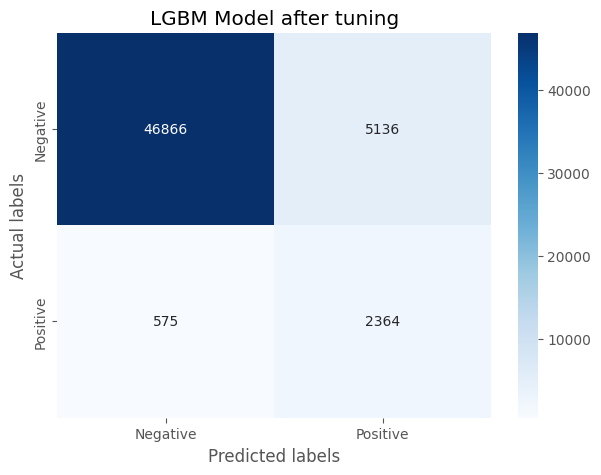

In [ ]:
# Confusion matrix visualization of LGBM

# Setting size
plt.figure(figsize=(7,5))

# Confusion matrix heatmap visualization
ax = sns.heatmap(confusion_matrix(y_test, y_pred_lgbm),
            xticklabels=['Negative', 'Positive'],  # Custom x-axis labels
    yticklabels=['Negative', 'Positive'],   # Custom y-axis labels
    cmap='Blues',
    annot=True,
    fmt='.0f'
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('Actual labels')
plt.title('LGBM Model after tuning')
plt.show()

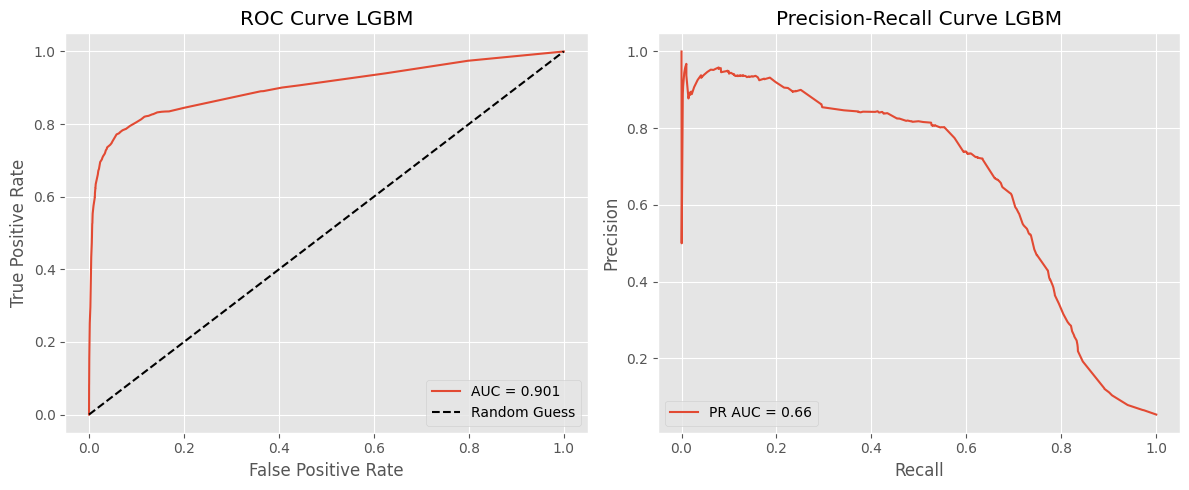

ROC-AUC Score: 0.901
PR-AUC Score: 0.66


In [ ]:
# ROC AUC vs PR AUC # LGBM


# Predictions
y_pred_proba_lgbm = tuned_model_lgbm.predict_proba(X_test)[:, 1]  # Probability of positive class

# ROC-AUC
roc_auc_lgbm = round(roc_auc_score(y_test, y_pred_proba_lgbm), 3)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lgbm)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lgbm)
pr_auc_lgbm = round(average_precision_score(y_test, y_pred_proba_lgbm), 3)

# Plot side by side 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Generating ROC Curve
ax[0].plot(fpr, tpr, label=f"AUC = {roc_auc_lgbm}")
ax[0].plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve LGBM")
ax[0].legend(loc="lower right")

# Generating Precision-Recall Curve
ax[1].plot(recall, precision, label=f"PR AUC = {pr_auc_lgbm}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve LGBM")
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Print AUC values
print(f"ROC-AUC Score: {roc_auc_lgbm}")
print(f"PR-AUC Score: {pr_auc_lgbm}")


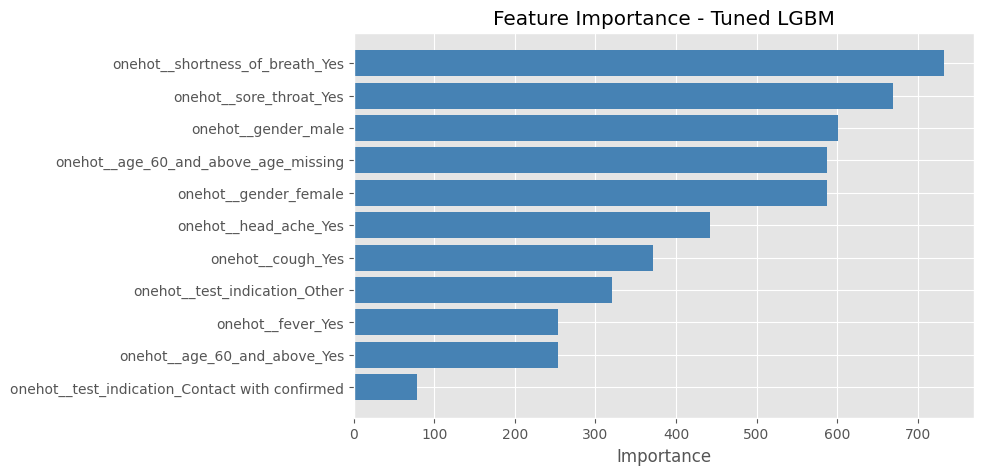

In [ ]:
# Feature importance # LGBM

# Extract fitted LGBM model from pipeline
lgbm_model = tuned_model_lgbm.named_steps['model']

# Get feature importances
importances = lgbm_model.feature_importances_

# Get feature names from ColumnTransformer (after OneHotEncoder)
encoder = tuned_model_lgbm.named_steps['prep'] # 'prep' is preprocessing step
feature_names = encoder.get_feature_names_out()

# Combine into a DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - Tuned LGBM")
plt.xlabel("Importance")
plt.show()

#### **Random Forest**

In [ ]:
# Hyperparameter tuning - Random forest

# Preprocessing
# Column Transformer
transformer = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first'), ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache',
       'age_60_and_above', 'gender', 'test_indication']),
], remainder='passthrough')
smotenc = SMOTENC(categorical_features=categorical_indices, random_state=0) # SMOTE for balancing data
#smotenc = SMOTENC(random_state=0, categorical_features=[0, 1, 2, 3, 4, 5, 6, 7, 8]) 
rf = RandomForestClassifier(random_state=0) # Random forest classifier


# Defining pipeline
estimator_rf = Pipeline([
    ('prep', transformer),
    ('resamplers', smotenc),
    ('model', rf)
])

# Adjusted hyperparameter space for Random Forest
hyperparam_space_rf = [{
    'model__n_estimators': [100, 200, 300],  # Number of trees
    'model__max_depth': [None, 10, 20, 30],  # Maximum depth of trees
    'model__min_samples_split': [2, 5, 10],  # Minimum number of samples to split an internal node
    'model__min_samples_leaf': [1, 2, 4],  # Minimum number of samples per leaf node
    'model__max_features': ['sqrt', 'log2'],  # Number of features to consider at each split
    'model__bootstrap': [True, False],  # Whether bootstrap samples are used
}]

# Hyperparameter tuning using RandomizedSearchCV
tuned_rf = RandomizedSearchCV(
    estimator_rf,
    n_jobs=-1,
    param_distributions=hyperparam_space_rf,
    scoring='recall',
    n_iter=50,
    cv=5,  # Cross-validation folds
    random_state=0,
)

# Fitting the tuned model
tuned_rf.fit(X_train, y_train)

# Best recall score on training set
print(f'Recall score - training set: {tuned_rf.best_score_:.3f}')
print(f'Best parameters: {tuned_rf.best_params_}')

Recall score - training set: 0.800
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__bootstrap': True}


In [ ]:
# Model after hyperparameter tuning
tuned_model_rf = tuned_rf.best_estimator_

# Fitting model
tuned_model_rf.fit(X_train, y_train)

# predict on test set
y_pred_rf = tuned_model_rf.predict(X_test)
y_pred_proba_rf =tuned_model_rf.predict_proba(X_test)[:, 1]  # Probabilities for ROC-AUC


# Evaluate recall score on test set
test_recall_rf = recall_score(y_test, y_pred_rf)
print(f'recall score: {test_recall_rf:.3f}')

recall score: 0.789


In [ ]:
# classification report
print("The Classification Report of Random Forest Classifier")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
print('The confusion matrix of Random Forest Classifier')
print(confusion_matrix(y_test, y_pred_rf))


The Classification Report of Random Forest Classifier
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     52002
           1       0.36      0.79      0.49      2939

    accuracy                           0.91     54941
   macro avg       0.67      0.85      0.72     54941
weighted avg       0.95      0.91      0.93     54941

The confusion matrix of Random Forest Classifier
[[47791  4211]
 [  621  2318]]


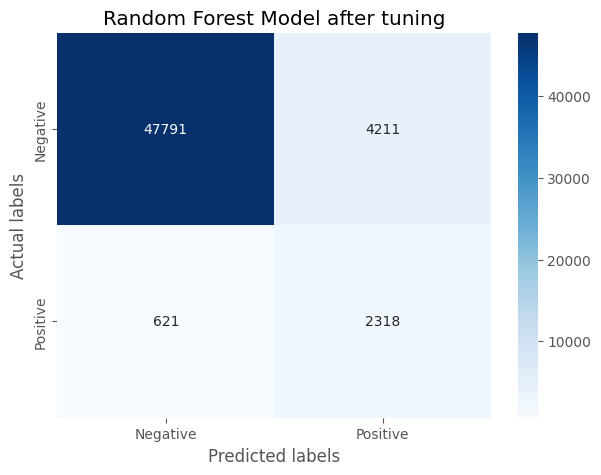

In [ ]:
# Confusion matrix visualization of Random Forest


# Setting size
plt.figure(figsize=(7,5))

# Confusion matrix heatmap visualization
ax = sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            xticklabels=['Negative', 'Positive'],  # Custom x-axis labels
    yticklabels=['Negative', 'Positive'],   # Custom y-axis labels
    cmap='Blues',
    annot=True,
    fmt='.0f'
)
ax.set_xlabel('Predicted labels')
ax.set_ylabel('Actual labels')
plt.title('Random Forest Model after tuning')
plt.show()

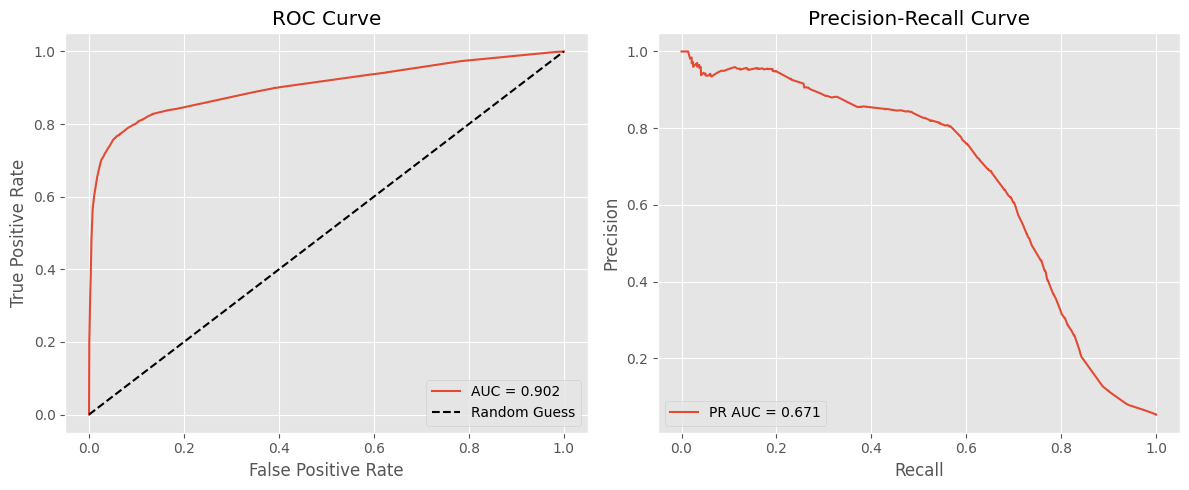

ROC-AUC Score: 0.902
PR-AUC Score: 0.671


In [ ]:
# ROC AUC vs Precision Recall - AUC Curve


# Predictions
y_pred_proba_rf = tuned_model_rf.predict_proba(X_test)[:, 1]  # Probability of positive class

# ROC-AUC
roc_auc_rf = round(roc_auc_score(y_test, y_pred_proba_rf), 3)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = round(average_precision_score(y_test, y_pred_proba_rf), 3)

# Plot side by side 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Generating ROC Curve
ax[0].plot(fpr, tpr, label=f"AUC = {roc_auc_rf}")
ax[0].plot([0, 1], [0, 1], 'k--', label="Random Guess")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve")
ax[0].legend(loc="lower right")

# Generating Precision-Recall Curve
ax[1].plot(recall, precision, label=f"PR AUC = {pr_auc_rf}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve")
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Print AUC values
print(f"ROC-AUC Score: {roc_auc_rf}")
print(f"PR-AUC Score: {pr_auc_rf}")


In [ ]:
# Baseline PR-AUC
baseline = y_test.mean()
print("Baseline (positive rate):", baseline)


Baseline (positive rate): 0.05349374783859049


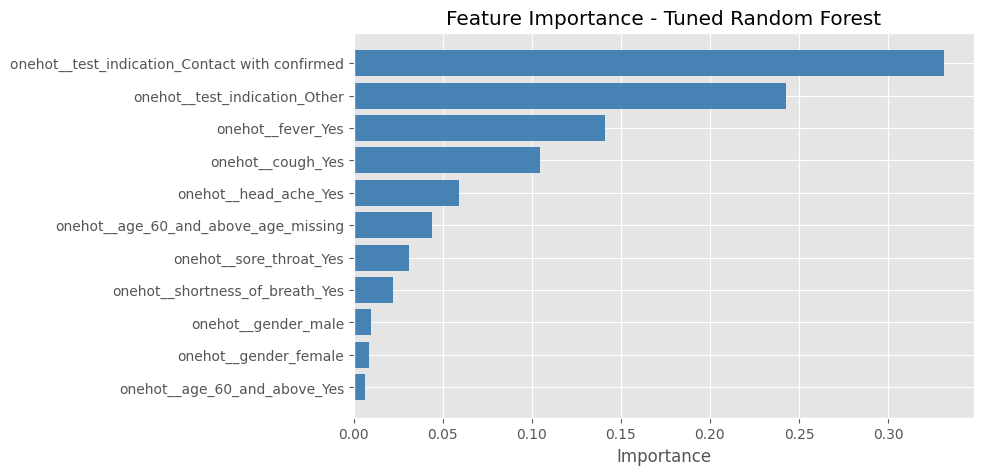

In [ ]:
# Feature importance # Random Forest

# Extract fitted RandomForest model from pipeline
rf_model = tuned_model_rf.named_steps['model']

# Get feature importances
importances = rf_model.feature_importances_

# Get feature names from ColumnTransformer (after OneHotEncoder)
encoder = tuned_model_rf.named_steps['prep'] # 'prep' is preprocessing step
feature_names = encoder.get_feature_names_out()

# Combine into a DataFrame
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")
plt.show()

## **Model Evaluation**


**Recall Comparison Before and After Tuning**

| Model          | Training Set | Testing Set |
|----------------|-----------------------------|-----------------------------|
| **XGBoost (Before Tuning)**   | 0.799 | 0.789 |
| **XGBoost (After Tuning)**    | 0.821 | 0.813 |
| **LightGBM (Before Tuning)**  | 0.797 | 0.789 |
| **LightGBM (After Tuning)**   | 0.818 | 0.804 |
| **Random Forest (Before Tuning)** | 0.795 | 0.786 |
| **Random Forest (After Tuning)**  | 0.800 | 0.789 |

**Insights**

After hyper parameter tuning, all models showed improvement in recall, particularly in the testing set. This means these tuned models became better at identifying positive COVID-19 (reducing false negative).

**Overall Model Performance After Tuning**

| Model         | Recall (Test) | Precision (Class 1) | ROC-AUC | PR-AUC | Key Insight |
|----------------|---------------|----------------------|----------|---------|--------------|
| **XGBoost**    | 0.813 | 0.29 | 0.896 | 0.629 | Highest recall; good at detecting positives but many false positives (low precision). |
| **LightGBM**   | 0.804 | 0.32 | 0.901 | 0.660 | Better balance between recall and precision; good generalization. |
| **Random Forest** | 0.789 | 0.36 | 0.902 | 0.671 | Most robust model overall. Best AUC and precision–recall balance. |

**Insight:**  
While XGBoost maximizes recall (catching most positive cases), it sacrifices precision, resulting in more false positives. The LGBM slightly better than XGBoost with more balance of recall and precision. In contrast, Random Forest offers the most stable and balanced performance across all metrics, making it the most reliable model prediction.


**Recommended final model**

Random Forest - This model provides the best trade-off between recall, precision, and AUC metrics in comparison to other models.

### **Learning Curve**

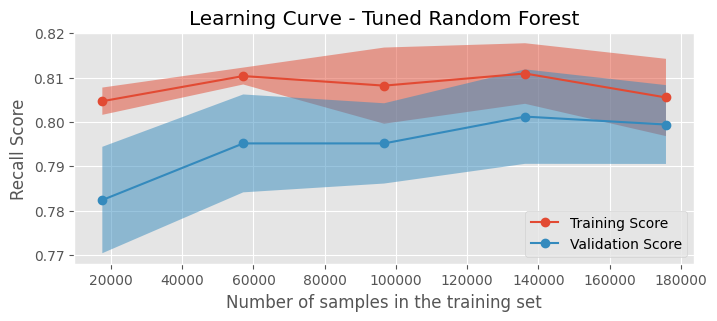

In [ ]:
# Generate learning curve Random forest # Recall score
from sklearn.model_selection import LearningCurveDisplay

# Set figure size
fig, ax = plt.subplots(figsize=(8, 3))

# Set the required parameters
common_params={
    "X": X_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1, 5), # 5 points of training data (use 10%, 32.5%, 55%, 77.5%, 100%)
    "cv": 5,
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {'marker': 'o'},
    "scoring": 'recall'
}

# Generate learning curve plot
LearningCurveDisplay.from_estimator(tuned_model_rf, **common_params, ax=ax)

# Set title and legend
handles, label = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['Training Score', 'Validation Score'])
ax.set_title(f'Learning Curve - Tuned Random Forest')
ax.set_ylabel('Recall Score')

# Show the plot
plt.show()

The learning curve above shows that our selected best model, the tuned Random Forest, achieves stable performance as training data increases. Both training and validation recall scores converge around 0.80–0.81, indicating good generalization and minimal overfitting. As more samples are added, the validation recall improves slightly while the training recall remains steady, suggesting the model is being consistent in predicting and benefits from more data.

### **Permutation Importance - Global Explanation**

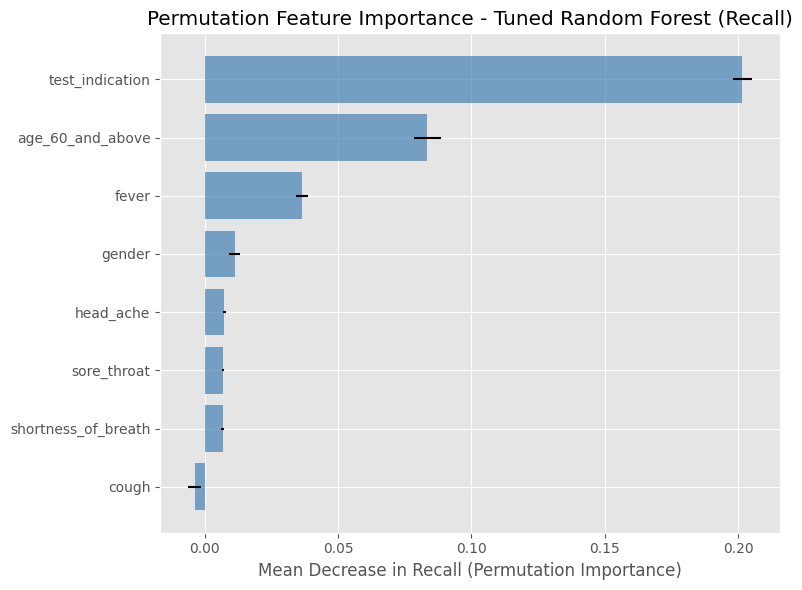

In [ ]:
# Permutation importance
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Final model is fitted
tuned_model_rf.fit(X_train, y_train)

# Compute permutation importance based on RECALL
r = permutation_importance(
    tuned_model_rf,
    X_test,
    y_test,
    scoring='recall',     # use recall as metric
    n_repeats=10,         # number of shuffles for stability
    random_state=42,
    n_jobs=-1
)

# Convert to DataFrame
perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': r.importances_mean,
    'importance_std': r.importances_std
}).sort_values('importance_mean', ascending=True)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(
    perm_df['feature'],
    perm_df['importance_mean'],
    xerr=perm_df['importance_std'],
    alpha=0.7,
    color='steelblue'
)
plt.xlabel('Mean Decrease in Recall (Permutation Importance)')
plt.title('Permutation Feature Importance - Tuned Random Forest (Recall)')
plt.tight_layout()
plt.show()


Permutation importance provides a global explanation of a model. It measures how much each feature contributes to the overall model performance by shuffling (permuting) one feature’s values and observing how the performance metric (e.g., accuracy, recall, etc.) changes. Because it evaluates the impact across the entire dataset, it reflects global feature importance, not just for a single instance.

The permutation importance plot above shows that `test_indication` is the most influential feature in determining the model’s recall, followed by `age_60_and_above` and `fever`, These variables contribute the most to correctly identifying positive COVID-19 cases. Meanwhile, features like `gender`, `head_ache`, `sore_throat`, `shortness_of_breath`, and `cough` have relatively minor effects on the model’s performance. Overall, this indicates that the context of testing (reason for test) and age-related risk are globally the strongest predictors in the tuned Random Forest model.


### **LIME - Local Explanation**

From the previous permutation importance, we can get crucial information of which features that contributes to the prediction. However, we cannot get the direction of each feature contribution to the prediction, whether the feature is supporting positive prediction or supporting negative prediction. That's why we are utilizing Local Interpretable Model-agnostic Explanations (LIME) technique for improving our machine learning explanation. The primary purpose of LIME is to interpret complex models by approximating them with simpler, interpretable models locally around the prediction of interest. For this step, we will use instances from patient data in the dataset (positive and negative) and explain which features and feature direction that contributes to the prediction of our machine learning model.

**LIME preparation**

In [264]:
# LIME preparation

# Define categorical columns 
categorical_cols = [
    'cough', 'fever', 'sore_throat', 'shortness_of_breath',
    'head_ache', 'age_60_and_above', 'gender', 'test_indication'
]

# Data preparation - Cleaning
# Strip whitespace and lowercase
X_train.columns = X_train.columns.str.strip().str.lower()
X_test.columns = X_test.columns.str.strip().str.lower()

# Check if all categorical columns exist
missing_cols = [col for col in categorical_cols if col not in X_train.columns]
if missing_cols:
    raise ValueError(f"Missing columns in X_train: {missing_cols}")
else:
    print("All categorical columns found in X_train!")

# Define ColumnTransformer
ct = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
], remainder='drop')

# Fit-transform and transform 
X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)

# Retrieve encoded feature names 
encoded_feature_names = ct.named_transformers_['onehot'].get_feature_names_out(categorical_cols)

# Create DataFrames - encoded
X_train_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

# Fitting model
model = RandomForestClassifier(max_depth=10, random_state=0)
model.fit(X_train_df, y_train)

print("Model trained successfully with encoded features:")
X_train_df.head()



All categorical columns found in X_train!
Model trained successfully with encoded features:


,cough_Yes,fever_Yes,sore_throat_Yes,shortness_of_breath_Yes,head_ache_Yes,age_60_and_above_Yes,age_60_and_above_age_missing,gender_female,gender_male,test_indication_Contact with confirmed,test_indication_Other
186185,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
63108,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
67504,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
76672,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
142309,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [265]:
# LIME explainer function
def explainer_lime(index):
    explainer = lime_tabular.LimeTabularExplainer(
        training_data = X_train_df.to_numpy(),
        feature_names = X_train_df.columns.to_list(),
        class_names=['Negative', 'Positive'],
        mode = 'classification'
    )

    exp = explainer.explain_instance(
        X_test_df.iloc[index].values,
        model.predict_proba,
        num_features = 10
    )
    
    print(f"The prediction must predict this patient is: {('Positive' if y_test.iloc[index] == 1 else 'Negative')} from y_test")
    print(' ')
    
    exp.as_pyplot_figure()
    exp.show_in_notebook(show_table=True)

We will use the example of positive prediction in the testing dataset.

In [ ]:
# Example of the positive prediction from the testing set
print('The features:')
display(X_test.iloc[[202]]) # row: 202

print('The prediction result:')
display(y_test.iloc[[202]]) # 1: positive, 0: Negative

The features:


,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above,gender,test_indication
230676,No,Yes,No,No,No,No,male,Contact with confirmed


The prediction result:


230676    1
Name: corona_result, dtype: int32

The prediction must predict this patient is: Positive from y_test
 


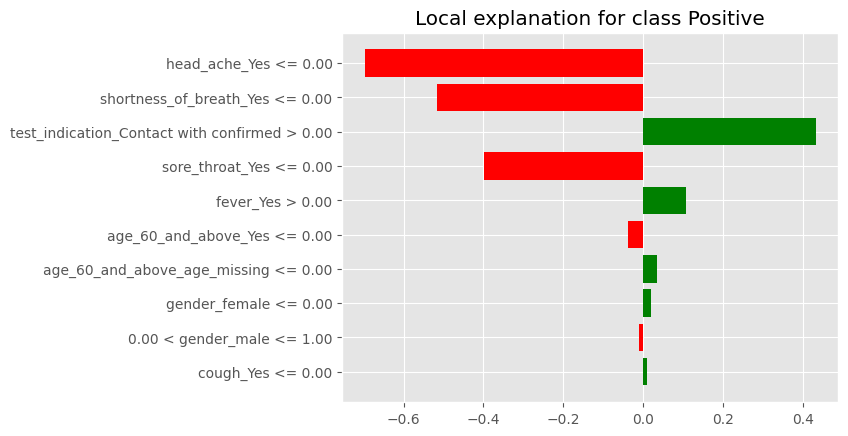

In [327]:
explainer_lime(202)

The model predicted this patient as COVID-19 positive (79% probability). Although the patient does not show several common symptoms (no cough, sore throat, shortness of breath, or headache), the model strongly focuses on exposure risk/history. Specifically, the feature “test_indication = Contact with confirmed case” and the presence of fever are the most influential factors pushing the prediction toward positive. These two features outweighed the negative effects from the absence of other symptoms. In simple terms, the model reasoned: “Even though this person doesn’t look very sick, they were in contact with a confirmed case and have a fever, so the risk of infection remains high.”

We will also check for the example of negative result

In [328]:
# Example of the positive prediction from the testing set
print('The features:')
display(X_test.iloc[[201]]) # row: 201

print('The prediction result:')
display(y_test.iloc[[201]]) # 1: positive, 0: Negative

The features:


,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above,gender,test_indication
20900,No,No,No,No,No,age_missing,female,Other


The prediction result:


20900    0
Name: corona_result, dtype: int32

The prediction must predict this patient is: Negative from y_test
 


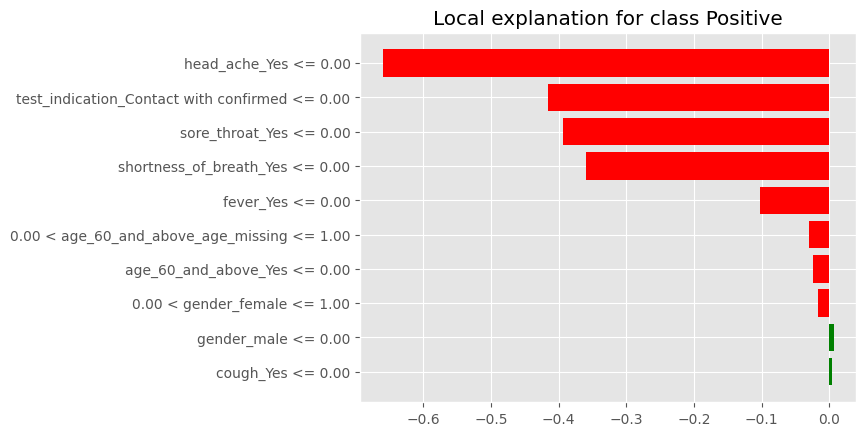

In [329]:
explainer_lime(201)

The model above predicted this patient as COVID-19 negative (99% probability). This prediction is driven by the absence of symptoms and lack of exposure risk. The patient shows no fever, cough, sore throat, shortness of breath, or headache, and their test indication is “Other”, meaning there is no known contact with a confirmed case or relevant travel history. These factors heavily contribute to the negative classification. The model also treats the patient’s “age_60_and_above = missing” and “gender = female” as minor neutral to negative factors, which do not increase the infection likelihood.

## **Conclusion**





**1. Influence of Demographic, Symptom, and Exposure History Features**

* Exposure history is the strongest predictor of COVID-19 results.
    * The feature `test_indication`: Contact with confirmed has the highest importance, showing that contact with a confirmed case is the key driver of positive outcomes.

    * `Age` also plays a significant role as people aged 60 and above have higher chances of testing positive.

    * Symptoms such as `fever`, `cough`, `sore throat`, `shortness of breath`, and `headache` also contribute to model but with less impact. less to the model.
This suggests that symptom presence alone is not enough to predict infection accurately without exposure and age information.

**2. Best-Performing Model**

* The tuned Random Forest classifier achieved the best overall performance on unseen data with parameters as
    * n_estimators: 100 
    * min_samples_split: 2 
    * min_samples_leaf: 1
    * max_features: 'sqrt'
    * max_depth: 10 
    * model__bootstrap: True

* The learning curve of the model also shows that both training and validation recall scores improve as sample size increases, with only a small gap between them. This indicates the model is well-generalized (not overfitting) and performs reliably in predicting COVID-19 outcomes.

**3. Key Features for Prediction Accuracy**

Based on Feature Importance, Permutation Importance (global explanation), and LIME (local explanation) analyses confirm that:

* `Test indication` (especially “Contact with confirmed”) is the most critical variable.

* `Age 60 and above` and `Fever` follow as secondary contributors.

* Other features like `gender`, `headache`, `sore throat`, and `shortness of breath` have minimal influence on recall performance.